In [1]:
import os
os.getcwd()

'G:\\My Drive\\bsd\\11_radiomics_for_gliomas\\02_train\\trial_100\\scripts'

In [2]:
import pandas as pd
all_cohorts = pd.read_csv('modeling_table.csv')
all_cohorts.shape
 

(1544, 4230)

In [3]:
all_cohorts['2021_glioma_class'].value_counts()
all_cohorts['Scanner'] = all_cohorts['Scanner'].replace('Other', 'GE')
 

In [4]:
all_cohorts.head(5)

,FLAIR_original_firstorder_10Percentile,FLAIR_original_firstorder_90Percentile,FLAIR_original_firstorder_Energy,FLAIR_original_firstorder_Entropy,FLAIR_original_firstorder_InterquartileRange,FLAIR_original_firstorder_Kurtosis,FLAIR_original_firstorder_Maximum,FLAIR_original_firstorder_MeanAbsoluteDeviation,FLAIR_original_firstorder_Mean,FLAIR_original_firstorder_Median,...,T2_wavelet-LLL_gldm_LowGrayLevelEmphasis,T2_wavelet-LLL_gldm_SmallDependenceEmphasis,T2_wavelet-LLL_gldm_SmallDependenceHighGrayLevelEmphasis,T2_wavelet-LLL_gldm_SmallDependenceLowGrayLevelEmphasis,case_id,site,2021_glioma_class,age,sex,Scanner
0,0.736154,2.818637,571334.478828,5.014156,1.257186,2.394337,4.774386,0.672184,1.776570,1.808323,...,0.001758,0.161286,151.451947,0.000328,BT0001,UTSW,glioblastoma,44.0,0,Siemens
1,0.488673,2.230858,23555.120764,4.935280,0.838735,5.300931,3.214054,0.558603,1.385858,1.474390,...,0.002055,0.211019,187.833381,0.000553,BT0002,UTSW,glioblastoma,58.0,1,GE
2,0.496658,2.797938,410631.266054,4.877536,1.208744,3.237318,4.928467,0.724986,1.581980,1.541386,...,0.001265,0.130759,147.092505,0.000249,BT0003,UTSW,astrocytoma,22.0,0,GE
3,0.464657,2.386642,482694.345238,5.081625,0.996302,3.306076,3.424597,0.599792,1.374134,1.373485,...,0.003784,0.141160,115.666222,0.000618,BT0005,UTSW,glioblastoma,67.0,1,GE
4,0.738694,2.959158,751600.309040,4.712456,1.178043,3.096775,4.804285,0.694520,1.891049,1.917817,...,0.002084,0.135099,111.399781,0.000460,BT0007,UTSW,astrocytoma,30.0,1,GE


In [5]:
feature_cols = [c for c in all_cohorts.columns if c not in [
    'Scanner', '2021_glioma_class', 'age', 'sex', 'case_id', 'site'
]]
#feature_cols

In [6]:
df_dev = all_cohorts[all_cohorts['site'].isin(['TCGA', 'UCSF'])].copy()
df_egd = all_cohorts[all_cohorts['site'] == 'EGD'].copy()
df_utsw = all_cohorts[all_cohorts['site'] == 'UTSW'].copy()
 

In [7]:
X_dev = df_dev[feature_cols]
y_dev = df_dev['2021_glioma_class']
 
X_ext_egd = df_egd[feature_cols]
y_ext_egd = df_egd['2021_glioma_class']
 
X_ext_utsw = df_utsw[feature_cols]
y_ext_utsw = df_utsw['2021_glioma_class']
 

In [8]:
from sklearn.model_selection import StratifiedKFold, train_test_split
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from mrmr import mrmr_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_dev_arr = y_dev.values
classes = np.unique(y_dev_arr)
n_classes = len(classes)
 
fold_assignments = np.zeros(len(y_dev_arr), dtype=int)
oof_probas = np.zeros((len(y_dev_arr), n_classes))
fold_models = []
fold_selected_features = []
 
rf_base = RandomForestClassifier(
    n_estimators=500, class_weight='balanced_subsample',
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_calibrated = CalibratedClassifierCV(estimator=rf_base, method='sigmoid', cv=5)
 
print("\nTraining 5 fold models with per-fold mRMR feature selection...")
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_dev, y_dev_arr)):
 
    print("fold")
 
    X_tr_full = X_dev.iloc[train_idx]
    y_tr = y_dev_arr[train_idx]
    X_val_full = X_dev.iloc[val_idx]
 
    # Missing value imputation
    imp = SimpleImputer(strategy='median')
    X_tr_full = X_tr_full[feature_cols].replace([np.inf, -np.inf], np.nan)
    X_val_full = X_val_full[feature_cols].replace([np.inf, -np.inf], np.nan)
    X_tr_full = pd.DataFrame(imp.fit_transform(X_tr_full), columns=X_tr_full.columns, index=X_tr_full.index)
    X_val_full = pd.DataFrame(imp.transform(X_val_full), columns=X_val_full.columns, index=X_val_full.index)
    print("MVI done")
    
    # valid features
    valid_features = X_tr_full.columns[X_tr_full.var() > 1e-5]
    X_tr_full = X_tr_full[valid_features]
    X_val_full = X_val_full[valid_features]
    
    # z=scaling
    dev_scaler = StandardScaler()
    X_tr_full = pd.DataFrame(dev_scaler.fit_transform(X_tr_full), columns=X_tr_full.columns, index=X_tr_full.index)
    X_val_full = pd.DataFrame(dev_scaler.transform(X_val_full), columns=X_val_full.columns, index=X_val_full.index)
    print("z-scaling done")
    
    X_tr_full = X_tr_full.loc[:, X_tr_full.var() > 1e-5]
    corr_mat = X_tr_full.corr().abs()
    upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    to_drop = [c for c in upper_tri.columns if any(upper_tri[c] > 0.85)]
    X_tr_full = X_tr_full.drop(columns=to_drop)
    X_val_full = X_val_full.drop(columns=to_drop)
 
    print("correlation filter for feature selection done")
    
    y_tr_series = pd.Series(y_tr, index=X_tr_full.index)
    fold_features = mrmr_classif(X=X_tr_full, y=y_tr_series, K=20, show_progress=False)
 
    print("Mrmr done")
    print(fold_features)
    
    model = clone(rf_calibrated)
    model.fit(X_tr_full[fold_features].values, y_tr)
    oof_probas[val_idx] = model.predict_proba(X_val_full[fold_features].values)
    fold_assignments[val_idx] = fold_idx
    fold_models.append(model)
    fold_selected_features.append(fold_features)
    print(f"  Fold {fold_idx+1}/5 trained ({len(fold_features)} features)")
 


Training 5 fold models with per-fold mRMR feature selection...
fold
MVI done
z-scaling done
correlation filter for feature selection done
Mrmr done
['T1CE_wavelet-LLH_glszm_ZoneEntropy', 'T2_wavelet-LHL_firstorder_Mean', 'T1CE_wavelet-LLH_firstorder_Skewness', 'T1CE_wavelet-HHH_glszm_GrayLevelNonUniformityNormalized', 'T1_original_firstorder_10Percentile', 'T1CE_original_firstorder_90Percentile', 'T1CE_wavelet-LHL_glszm_ZoneEntropy', 'T1CE_wavelet-LLH_glszm_GrayLevelNonUniformityNormalized', 'T1CE_original_firstorder_10Percentile', 'T1CE_log-sigma-1-0-mm-3D_glcm_Imc2', 'T1CE_wavelet-HHH_glcm_Autocorrelation', 'T2_original_firstorder_10Percentile', 'T1CE_log-sigma-1-0-mm-3D_glszm_GrayLevelNonUniformityNormalized', 'T1CE_log-sigma-2-0-mm-3D_firstorder_Maximum', 'T1CE_wavelet-LHL_glszm_GrayLevelNonUniformityNormalized', 'T1CE_original_firstorder_Skewness', 'T1CE_wavelet-HLL_glszm_GrayLevelNonUniformityNormalized', 'T1CE_wavelet-LHH_glszm_ZoneEntropy', 'T1CE_wavelet-LLH_glcm_Imc2', 'T1CE_

In [9]:
#oof_probas

In [10]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer
 
def compute_argmax_and_auc(y_true, y_probas, classes, weights=None):
    y_true_arr = np.array(y_true)
    
    # --- 1. Compute Argmax Predictions ---
    if weights is None:
        weight_vec = np.ones(len(classes))
    else:
        weight_vec = np.array(weights, dtype=float)
        
    # Get the predicted class labels
    y_pred_arr = classes[np.argmax(y_probas * weight_vec, axis=1)]
 
    # --- 2. Compute AUC ---
    # Binarize the true labels to compute per-class AUC
    lb = LabelBinarizer().fit(classes)
    y_true_bin = lb.transform(y_true_arr)
    
    results = {}
    
    # Calculate per-class AUC
    for i, cls in enumerate(classes):
        # Prevent errors if a class is entirely missing from y_true
        if len(np.unique(y_true_bin[:, i])) > 1:
            results[cls] = roc_auc_score(y_true_bin[:, i], y_probas[:, i])
        else:
            results[cls] = float('nan')
            
    # Calculate overall Macro AUC (average of the per-class AUCs)
    try:
        # multi_class='ovr' handles the 3-class problem seamlessly
        overall_auc = roc_auc_score(y_true_arr, y_probas, multi_class='ovr', labels=classes)
        results['overall_macro_auc'] = overall_auc
    except ValueError:
        results['overall_macro_auc'] = float('nan')
 
    return y_pred_arr, results
 
 
classes = np.unique(y_dev_arr)
y_preds, auc_results = compute_argmax_and_auc(y_dev_arr, oof_probas, classes)
print(auc_results)

{'astrocytoma': 0.9492245257495203, 'glioblastoma': 0.9569905938665331, 'oligodendroglioma': 0.8781065088757396, 'overall_macro_auc': 0.9281072094972643}


In [11]:
# Now we train on full training cohort and then predict on external sets
 
X_tr_full = X_dev
y_tr = y_dev_arr
 
# Missing value imputation
imp = SimpleImputer(strategy='median')
X_tr_full = X_tr_full[feature_cols].replace([np.inf, -np.inf], np.nan)
X_ext_egd = X_ext_egd[feature_cols].replace([np.inf, -np.inf], np.nan)
X_ext_utsw = X_ext_utsw[feature_cols].replace([np.inf, -np.inf], np.nan)
 
X_tr_full = pd.DataFrame(imp.fit_transform(X_tr_full), columns=X_tr_full.columns, index=X_tr_full.index)
X_ext_egd = pd.DataFrame(imp.transform(X_ext_egd), columns=X_ext_egd.columns, index=X_ext_egd.index)
X_ext_utsw = pd.DataFrame(imp.transform(X_ext_utsw), columns=X_ext_utsw.columns, index=X_ext_utsw.index)
print("MVI done")
 
# valid features
valid_features = X_tr_full.columns[X_tr_full.var() > 1e-5]
X_tr_full = X_tr_full[valid_features]
X_ext_egd = X_ext_egd[valid_features]
X_ext_utsw = X_ext_utsw[valid_features]
 
# z=scaling
dev_scaler = StandardScaler()
X_tr_full = pd.DataFrame(dev_scaler.fit_transform(X_tr_full), columns=X_tr_full.columns, index=X_tr_full.index)
X_ext_egd = pd.DataFrame(dev_scaler.transform(X_ext_egd), columns=X_ext_egd.columns, index=X_ext_egd.index)
X_ext_utsw = pd.DataFrame(dev_scaler.transform(X_ext_utsw), columns=X_ext_utsw.columns, index=X_ext_utsw.index)
print("z-scaling done")
 
X_tr_full = X_tr_full.loc[:, X_tr_full.var() > 1e-5]
corr_mat = X_tr_full.corr().abs()
upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop = [c for c in upper_tri.columns if any(upper_tri[c] > 0.85)]
X_tr_full = X_tr_full.drop(columns=to_drop)
X_ext_egd = X_ext_egd.drop(columns=to_drop)
X_ext_utsw = X_ext_utsw.drop(columns=to_drop)
 
print("correlation filter for feature selection done")
 
y_tr_series = pd.Series(y_tr, index=X_tr_full.index)
final_features = mrmr_classif(X=X_tr_full, y=y_tr_series, K=20, show_progress=False)
 
print("Mrmr done")
print(final_features)
 
final_model = clone(rf_calibrated)
final_model.fit(X_tr_full[final_features], y_dev_arr)
print(f"  Final model: {len(final_features)} features")
 
# feature-selection stability across folds (how often each final feature appeared)
fold_feature_sets = [set(f) for f in fold_selected_features]
feature_stability = {
    feat: sum(feat in fs for fs in fold_feature_sets) / 5.0 for feat in final_features
}
n_stable = sum(1 for v in feature_stability.values() if v >= 0.8)
print(f"  Stability: {n_stable}/{len(final_features)} features selected in >=4/5 folds")
 
egd_full_probas = final_model.predict_proba(X_ext_egd[final_features])
utsw_full_probas = final_model.predict_proba(X_ext_utsw[final_features])
 
y_ext_full = df_egd['2021_glioma_class'].values
y_utsw_full = df_utsw['2021_glioma_class'].values

MVI done
z-scaling done
correlation filter for feature selection done
Mrmr done
['T1CE_original_firstorder_90Percentile', 'T1_wavelet-LLL_glszm_ZoneEntropy', 'T2_log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformityNormalized', 'T1CE_wavelet-LLH_glszm_ZoneEntropy', 'T1CE_original_firstorder_10Percentile', 'T1CE_log-sigma-1-0-mm-3D_glcm_Imc2', 'T2_original_firstorder_10Percentile', 'T1CE_wavelet-LHL_glszm_ZoneEntropy', 'T1CE_log-sigma-1-0-mm-3D_glszm_GrayLevelNonUniformityNormalized', 'T1_original_firstorder_10Percentile', 'T1CE_wavelet-LLH_glszm_GrayLevelNonUniformityNormalized', 'T1CE_original_firstorder_Skewness', 'T1CE_wavelet-HLL_glszm_GrayLevelNonUniformityNormalized', 'T1CE_log-sigma-2-0-mm-3D_firstorder_Maximum', 'T1CE_wavelet-LHH_glszm_ZoneEntropy', 'T1CE_wavelet-LHL_glszm_GrayLevelNonUniformityNormalized', 'T1CE_wavelet-LLH_glcm_Imc2', 'T1_original_firstorder_RootMeanSquared', 'T1CE_original_firstorder_Maximum', 'T1CE_wavelet-HLL_glszm_ZoneEntropy']
  Final model: 20 features
  Sta

In [12]:
y_egd_full = df_egd['2021_glioma_class'].values
y_utsw_full = df_utsw['2021_glioma_class'].values
 
classes = np.unique(y_egd_full)
y_preds, auc_results = compute_argmax_and_auc(y_egd_full, egd_full_probas, classes)
print(auc_results)
 
classes = np.unique(y_utsw_full)
y_preds, auc_results = compute_argmax_and_auc(y_utsw_full, utsw_full_probas, classes)
print(auc_results)

{'astrocytoma': 0.9198141308233051, 'glioblastoma': 0.9634120734908136, 'oligodendroglioma': 0.872863468940115, 'overall_macro_auc': 0.9186965577514111}
{'astrocytoma': 0.9039765544190322, 'glioblastoma': 0.9127065736320236, 'oligodendroglioma': 0.816302200422372, 'overall_macro_auc': 0.8776617761578093}


In [13]:
print(egd_full_probas.shape)

(404, 3)


In [14]:
# Assuming y_true (labels) and y_pred_proba (probabilities) exist
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
 
# Binarize
lb = LabelBinarizer()
y_bin = lb.fit_transform(y_dev_arr)
 
print(y_dev_arr.shape)
print(np.unique(y_dev_arr))
print(y_bin.shape)
print(y_bin[0,:])
print(oof_probas.shape)
print(oof_probas[0,:])
 

(611,)
['astrocytoma' 'glioblastoma' 'oligodendroglioma']
(611, 3)
[0 1 0]
(611, 3)
[0.14037261 0.6571162  0.20251119]


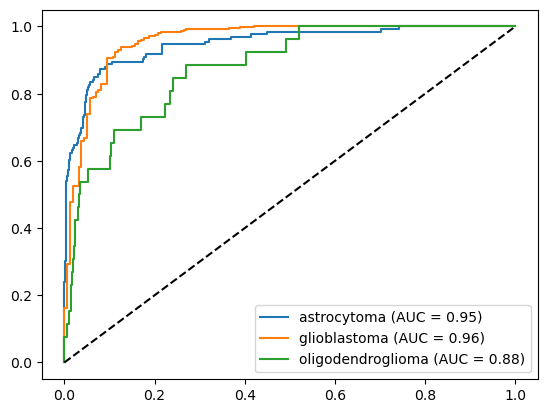

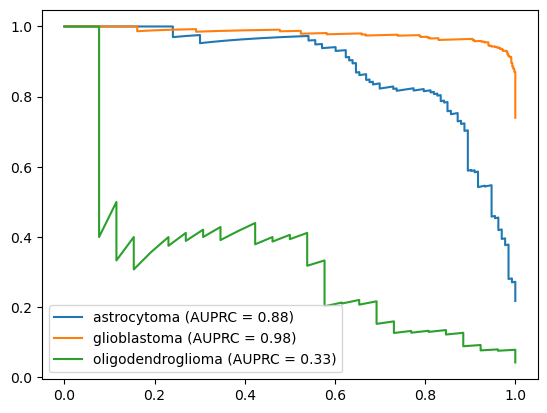

In [15]:
# Assuming y_true (labels) and y_pred_proba (probabilities) exist
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
 
# Binarize
lb = LabelBinarizer()
y_bin = lb.fit_transform(y_dev_arr)
 
# Plot each class
for i in range(len(lb.classes_)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], oof_probas[:, i])
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{lb.classes_[i]} (AUC = {score:.2f})')
 
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.show()
 
 
 
# Plot PR curve for each class
for i in range(len(lb.classes_)):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], oof_probas[:, i])
    score = auc(recall, precision) # Note: recall must be the x-axis parameter
    plt.plot(recall, precision, label=f'{lb.classes_[i]} (AUPRC = {score:.2f})')
 
plt.legend()
plt.show()

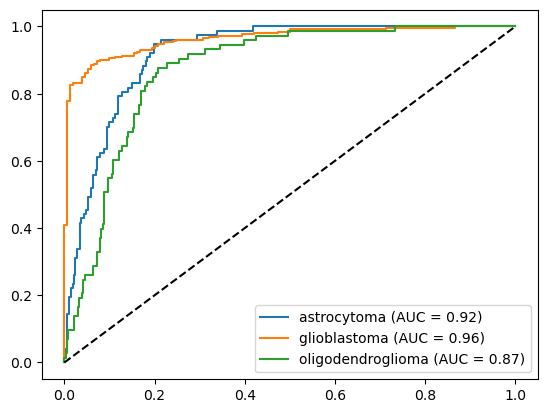

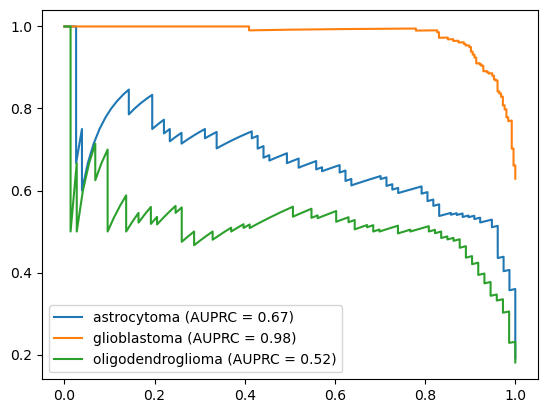

In [16]:
# Assuming y_true (labels) and y_pred_proba (probabilities) exist
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
 
# Binarize
lb = LabelBinarizer()
y_bin = lb.fit_transform(y_egd_full)
 
# Plot each class
for i in range(len(lb.classes_)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], egd_full_probas[:, i])
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{lb.classes_[i]} (AUC = {score:.2f})')
 
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.show()
 
 
# Plot PR curve for each class
for i in range(len(lb.classes_)):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], egd_full_probas[:, i])
    score = auc(recall, precision) # Note: recall must be the x-axis parameter
    plt.plot(recall, precision, label=f'{lb.classes_[i]} (AUPRC = {score:.2f})')
 
plt.legend()
plt.show()
 

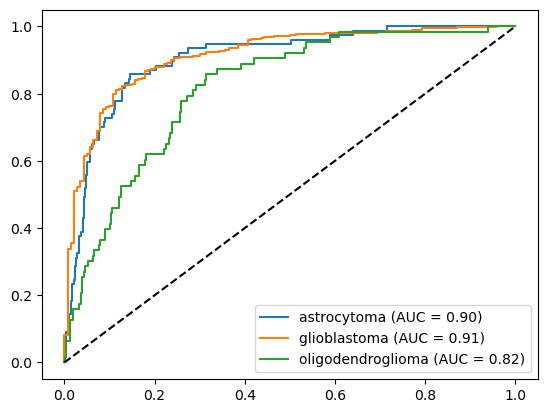

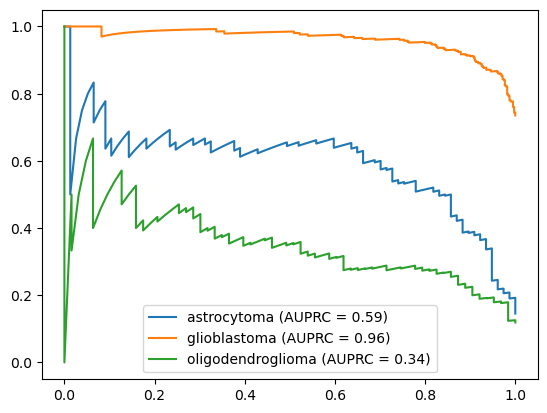

In [17]:
# Assuming y_true (labels) and y_pred_proba (probabilities) exist
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
 
# Binarize
lb = LabelBinarizer()
y_bin = lb.fit_transform(y_utsw_full)
 
# Plot each class
for i in range(len(lb.classes_)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], utsw_full_probas[:, i])
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{lb.classes_[i]} (AUC = {score:.2f})')
 
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.show()
 
# Plot PR curve for each class
for i in range(len(lb.classes_)):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], utsw_full_probas[:, i])
    score = auc(recall, precision) # Note: recall must be the x-axis parameter
    plt.plot(recall, precision, label=f'{lb.classes_[i]} (AUPRC = {score:.2f})')
 
plt.legend()
plt.show()

In [18]:
# def compute_argmax(y_true, y_probas, classes, weights=None):
y_true = y_egd_full
y_probas = egd_full_probas
 
y_true_arr = np.array(y_true)
 
weights=None
# --- 1. Compute Argmax Predictions ---
if weights is None:
    weight_vec = np.ones(len(classes))
else:
    weight_vec = np.array(weights, dtype=float)
    
# Get the predicted class labels
y_pred_arr = classes[np.argmax(y_probas * weight_vec, axis=1)]
 
 
print(np.unique(y_egd_full))
print(y_egd_full.shape)
print(y_egd_full[0])
 
print(y_probas.shape)
print(y_probas[0,:])
 
check = y_probas*weight_vec
print(check.shape)
print(check[0,:])
y_pred_arr = classes[np.argmax(y_probas * weight_vec, axis=1)]
print(y_pred_arr.shape)
print(y_pred_arr[0])

['astrocytoma' 'glioblastoma' 'oligodendroglioma']
(404,)
oligodendroglioma
(404, 3)
[0.36094271 0.47488339 0.16417391]
(404, 3)
[0.36094271 0.47488339 0.16417391]
(404,)
glioblastoma


In [19]:
from itertools import product
from sklearn.metrics import balanced_accuracy_score
 
n_classes
weight_grid_values = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0]
candidate_weight_vectors = list(product(weight_grid_values, repeat=n_classes))
# print(candidate_weight_vectors)
 
best_bal_acc_dev = -1.0
best_weights_dev = np.ones(n_classes)
for w in candidate_weight_vectors:
    w_arr = np.array(w, dtype=float)
    y_pred_w = classes[np.argmax(oof_probas * w_arr, axis=1)]
    bal = balanced_accuracy_score(y_dev_arr, y_pred_w)
    if bal > best_bal_acc_dev:
        best_bal_acc_dev = bal
        best_weights_dev = w_arr
 
ratios_dev = best_weights_dev / best_weights_dev.max()
argmax_bal_dev = balanced_accuracy_score(y_dev_arr, classes[np.argmax(oof_probas, axis=1)])
print("\n[A] Weights selected on development OOF (frozen, applied to full external cohorts)")
for i, cls in enumerate(classes):
    print(f"  {cls:<18} relative weight = {ratios_dev[i]:.2f}")
print(f"  Balanced accuracy (dev OOF): argmax = {argmax_bal_dev:.3f} -> weighted = {best_bal_acc_dev:.3f}")
 


[A] Weights selected on development OOF (frozen, applied to full external cohorts)
  astrocytoma        relative weight = 0.25
  glioblastoma       relative weight = 0.08
  oligodendroglioma  relative weight = 1.00
  Balanced accuracy (dev OOF): argmax = 0.628 -> weighted = 0.753


In [20]:
from sklearn.metrics import average_precision_score   # add to imports

def evaluate_base_classifier(y_true, y_probas, classes, n_iterations=1000, alpha=0.95, weights=None):
    n_samples = len(y_true)
    y_true_arr = np.array(y_true)
    # weights=None is plain argmax 
    
    if weights is None:
        weight_vec = np.ones(len(classes))
    else:
        weight_vec = np.array(weights, dtype=float)
    y_pred_arr = classes[np.argmax(y_probas * weight_vec, axis=1)]
    lb = LabelBinarizer().fit(classes)
    y_true_bin = lb.transform(y_true_arr)
    stats = {cls: {'auc': [], 'auprc': [], 'sens': [], 'spec': [], 'ppv': [], 'npv': []} for cls in classes}

    for _ in range(n_iterations):
        indices = np.random.randint(0, n_samples, n_samples)
        y_true_boot = y_true_arr[indices]
        y_pred_boot = y_pred_arr[indices]
        y_true_bin_boot = y_true_bin[indices]
        y_probas_boot = y_probas[indices]
        for i, cls in enumerate(classes):
            if len(np.unique(y_true_bin_boot[:, i])) > 1:
                fpr, tpr, _ = roc_curve(y_true_bin_boot[:, i], y_probas_boot[:, i])
                stats[cls]['auc'].append(auc(fpr, tpr))
                # AUPRC (average precision).. same one-vs-rest column, same bootstrap sample.
                # Baseline for a no-skill model is the class prevalence.. not 0.5.
                stats[cls]['auprc'].append(average_precision_score(y_true_bin_boot[:, i], y_probas_boot[:, i]))
            tp = np.sum((y_pred_boot == cls) & (y_true_boot == cls))
            fp = np.sum((y_pred_boot == cls) & (y_true_boot != cls))
            tn = np.sum((y_pred_boot != cls) & (y_true_boot != cls))
            fn = np.sum((y_pred_boot != cls) & (y_true_boot == cls))
            # sensitivity and PPV share the same TP but different denominators
            # sensitivity is over true class members (stable), PPV over argmax
            # predictions of the class (tiny for the minority class).
            if (tp + fn) > 0: stats[cls]['sens'].append(tp / (tp + fn))
            if (tn + fp) > 0: stats[cls]['spec'].append(tn / (tn + fp))
            if (tp + fp) > 0: stats[cls]['ppv'].append(tp / (tp + fp))
            if (tn + fn) > 0: stats[cls]['npv'].append(tn / (tn + fn))

    results = {}
    raw = {}
    lower_p = ((1.0 - alpha) / 2.0) * 100
    upper_p = (alpha + ((1.0 - alpha) / 2.0)) * 100
    for cls in classes:
        results[cls] = {}
        raw[cls] = {}
        for metric in ['auc', 'auprc', 'sens', 'spec', 'ppv', 'npv']:
            if len(stats[cls][metric]) > 0:
                mean_val = float(np.mean(stats[cls][metric]))
                lower_ci = float(np.percentile(stats[cls][metric], lower_p))
                upper_ci = float(np.percentile(stats[cls][metric], upper_p))
                raw[cls][metric] = {'mean': mean_val, 'lo': lower_ci, 'hi': upper_ci}
                results[cls][metric] = f"{mean_val:.2f} [{lower_ci:.2f}-{upper_ci:.2f}]"
            else:
                results[cls][metric] = "N/A"
                raw[cls][metric] = {'mean': float('nan'), 'lo': float('nan'), 'hi': float('nan')}
    return results, raw

In [21]:
base_dev_res, base_dev_raw = evaluate_base_classifier(y_dev_arr, oof_probas, classes, alpha=0.95)
base_ext_res, base_ext_raw = evaluate_base_classifier(y_egd_full, egd_full_probas, classes, alpha=0.95)
base_utsw_res, base_utsw_raw = evaluate_base_classifier(y_utsw_full, utsw_full_probas, classes, alpha=0.95)
 
for label, res, n in [("Dev OOF", base_dev_res, len(y_dev_arr)),
                      ("EGD full cohort", base_ext_res, len(y_egd_full)),
                      ("UTSW full cohort", base_utsw_res, len(y_utsw_full))]:
    print(f"\n[{label}, n = {n}]")
    print(f"  {'Class':<18} | {'AUC':<14} | {'Sens':<14} | {'Spec':<14} | {'PPV':<14} | {'NPV':<14}")
    for cls in classes:
        r = res[cls]
        print(f"  {cls:<18} | {r['auc']:<14} | {r['sens']:<14} | {r['spec']:<14} | {r['ppv']:<14} | {r['npv']:<14}")

metric_rows = []
for label, res, y_true, n in [
        ("Dev OOF",          base_dev_res,  y_dev_arr,   len(y_dev_arr)),
        ("EGD full cohort",  base_ext_res,  y_egd_full,  len(y_egd_full)),
        ("UTSW full cohort", base_utsw_res, y_utsw_full, len(y_utsw_full))]:
    y_true_arr = np.array(y_true)
    for cls in classes:
        r = res[cls]
        n_class = int(np.sum(y_true_arr == cls))
        prevalence = n_class / n
        row = {}
        row['Cohort'] = label
        row['n (cohort)'] = n
        row['Class'] = cls
        row['N (class)'] = n_class
        row['Prevalence'] = round(prevalence, 3)
        row['AUC'] = r['auc']
        row['AUPRC'] = r['auprc']
        row['Sens'] = r['sens']
        row['Spec'] = r['spec']
        row['PPV'] = r['ppv']
        row['NPV'] = r['npv']
        metric_rows.append(row)

base_metrics_df = pd.DataFrame(metric_rows)
base_metrics_df.to_csv(os.path.join(os.getcwd(), 'base_classifier_metrics.csv'), index=False)
print('\nwrote base_classifier_metrics.csv -', len(base_metrics_df), 'rows')


[Dev OOF, n = 611]
  Class              | AUC            | Sens           | Spec           | PPV            | NPV           
  astrocytoma        | 0.95 [0.93-0.97] | 0.79 [0.72-0.86] | 0.95 [0.93-0.97] | 0.82 [0.75-0.88] | 0.94 [0.92-0.96]
  glioblastoma       | 0.96 [0.94-0.97] | 0.98 [0.97-0.99] | 0.79 [0.73-0.85] | 0.93 [0.91-0.95] | 0.93 [0.89-0.97]
  oligodendroglioma  | 0.88 [0.81-0.93] | 0.12 [0.00-0.25] | 1.00 [0.99-1.00] | 0.60 [0.00-1.00] | 0.96 [0.95-0.98]

[EGD full cohort, n = 404]
  Class              | AUC            | Sens           | Spec           | PPV            | NPV           
  astrocytoma        | 0.92 [0.89-0.94] | 0.79 [0.70-0.88] | 0.86 [0.83-0.90] | 0.58 [0.49-0.67] | 0.95 [0.92-0.97]
  glioblastoma       | 0.96 [0.95-0.98] | 0.96 [0.93-0.98] | 0.71 [0.63-0.78] | 0.85 [0.80-0.88] | 0.91 [0.86-0.96]
  oligodendroglioma  | 0.87 [0.84-0.91] | 0.10 [0.04-0.17] | 0.99 [0.98-1.00] | 0.70 [0.38-1.00] | 0.83 [0.80-0.87]

[UTSW full cohort, n = 529]
  Class        

In [22]:
# apply the frozen dev weights, with bootstrap CIs, on dev OOF and full external cohorts
wt_dev_res,  wt_dev_raw  = evaluate_base_classifier(y_dev_arr,   oof_probas,       classes, alpha=0.95, weights=best_weights_dev)
wt_ext_res,  wt_ext_raw  = evaluate_base_classifier(y_egd_full,  egd_full_probas,  classes, alpha=0.95, weights=best_weights_dev)
wt_utsw_res, wt_utsw_raw = evaluate_base_classifier(y_utsw_full, utsw_full_probas, classes, alpha=0.95, weights=best_weights_dev)
 
for label, base_res, wt_res, n in [
        ("Dev OOF",          base_dev_res,  wt_dev_res,  len(y_dev_arr)),
        ("EGD full cohort",  base_ext_res,  wt_ext_res,  len(y_egd_full)),
        ("UTSW full cohort", base_utsw_res, wt_utsw_res, len(y_utsw_full))]:
    print(f"\n[{label}, n = {n}]  argmax -> weighted argmax (frozen dev weights)")
    print(f"  {'Class':<18} | {'Sens argmax':<16} | {'Sens weighted':<16} | {'Spec argmax':<16} | {'Spec weighted':<16}")
    for cls in classes:
        print(f"  {cls:<18} | {base_res[cls]['sens']:<16} | {wt_res[cls]['sens']:<16} | {base_res[cls]['spec']:<16} | {wt_res[cls]['spec']:<16}")


# save the argmax -> weighted comparison to CSV (one row per cohort x class)
weighted_rows = []
for label, base_res, wt_res, y_true, n in [
        ("Dev OOF",          base_dev_res,  wt_dev_res,  y_dev_arr,   len(y_dev_arr)),
        ("EGD full cohort",  base_ext_res,  wt_ext_res,  y_egd_full,  len(y_egd_full)),
        ("UTSW full cohort", base_utsw_res, wt_utsw_res, y_utsw_full, len(y_utsw_full))]:
    y_true_arr = np.array(y_true)
    for cls in classes:
        n_class = int(np.sum(y_true_arr == cls))
        row = {}
        row['Cohort'] = label
        row['n (cohort)'] = n
        row['Class'] = cls
        row['N (class)'] = n_class
        row['Sens argmax'] = base_res[cls]['sens']
        row['Sens weighted'] = wt_res[cls]['sens']
        row['Spec argmax'] = base_res[cls]['spec']
        row['Spec weighted'] = wt_res[cls]['spec']
        weighted_rows.append(row)

weighted_compare_df = pd.DataFrame(weighted_rows)
weighted_compare_df.to_csv(os.path.join(os.getcwd(), 'weighted_argmax_comparison.csv'), index=False)
print('\nwrote weighted_argmax_comparison.csv -', len(weighted_compare_df), 'rows')



[Dev OOF, n = 611]  argmax -> weighted argmax (frozen dev weights)
  Class              | Sens argmax      | Sens weighted    | Spec argmax      | Spec weighted   
  astrocytoma        | 0.79 [0.72-0.86] | 0.72 [0.64-0.80] | 0.95 [0.93-0.97] | 0.96 [0.94-0.97]
  glioblastoma       | 0.98 [0.97-0.99] | 0.92 [0.90-0.95] | 0.79 [0.73-0.85] | 0.88 [0.83-0.93]
  oligodendroglioma  | 0.12 [0.00-0.25] | 0.61 [0.42-0.81] | 1.00 [0.99-1.00] | 0.93 [0.91-0.95]

[EGD full cohort, n = 404]  argmax -> weighted argmax (frozen dev weights)
  Class              | Sens argmax      | Sens weighted    | Spec argmax      | Spec weighted   
  astrocytoma        | 0.79 [0.70-0.88] | 0.75 [0.66-0.84] | 0.86 [0.83-0.90] | 0.86 [0.82-0.89]
  glioblastoma       | 0.96 [0.93-0.98] | 0.87 [0.83-0.91] | 0.71 [0.63-0.78] | 0.97 [0.95-0.99]
  oligodendroglioma  | 0.10 [0.04-0.17] | 0.53 [0.41-0.64] | 0.99 [0.98-1.00] | 0.89 [0.86-0.92]

[UTSW full cohort, n = 529]  argmax -> weighted argmax (frozen dev weights)
  C

In [23]:
import warnings
warnings.filterwarnings('ignore')

In [24]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from crepes import ConformalClassifier
import warnings
warnings.filterwarnings('ignore')


def conformal_point_metrics(y_true, pred_sets, classes):
    y_true_arr = np.array(y_true)
    set_sizes_all = pred_sets.sum(axis=1)
    out = {}
    for i, cls in enumerate(classes):
        cls_mask = (y_true_arr == cls)
        if np.sum(cls_mask) == 0:
            out[cls] = {'cov': np.nan, 'size': np.nan, 'size_ge1': np.nan,
                        'pct_0': np.nan, 'pct_1': np.nan, 'pct_2': np.nan, 'pct_all': np.nan}
            continue
        sizes = set_sizes_all[cls_mask]
        nonempty_sizes = sizes[sizes >= 1]
        if len(nonempty_sizes) > 0:
            size_ge1 = float(np.mean(nonempty_sizes))
        else:
            size_ge1 = np.nan
        out[cls] = {
            'cov': float(np.mean(pred_sets[cls_mask, i])),
            'size': float(np.mean(sizes)),
            'size_ge1': size_ge1,
            'pct_0': float(np.mean(sizes == 0) * 100),
            'pct_1': float(np.mean(sizes == 1) * 100),
            'pct_2': float(np.mean(sizes == 2) * 100),
            'pct_all': float(np.mean(sizes == 3) * 100),
        }
    return out


# --- preprocess EGD exactly as before ---
X_ext_egd = df_egd[feature_cols].replace([np.inf, -np.inf], np.nan)
X_ext_egd = pd.DataFrame(imp.transform(X_ext_egd), columns=X_ext_egd.columns, index=X_ext_egd.index)
X_ext_egd = X_ext_egd[valid_features]
X_ext_egd = pd.DataFrame(dev_scaler.transform(X_ext_egd), columns=X_ext_egd.columns, index=X_ext_egd.index)
X_ext_egd = X_ext_egd.drop(columns=to_drop)
X_ext_egd = X_ext_egd[final_features]
y_ext_egd = df_egd['2021_glioma_class']

classes = np.unique(y_dev_arr)
target_confidences = [0.80, 0.85, 0.90, 0.95]
n_seeds = 200

# model probabilities for the whole external cohort.. computed ONCE
full_probas = final_model.predict_proba(X_ext_egd[final_features].values)
full_scores = 1 - full_probas
y_all = y_ext_egd.values
row_index = np.arange(len(y_all))

# collect rows separately for each confidence leve
results_by_conf = {}
for target_confidence in target_confidences:
    results_by_conf[target_confidence] = []

# one split and one calibration fit per seed, reused across confidences
for seed in range(n_seeds):

    idx_cal, idx_test = train_test_split(
        row_index, test_size=0.5, random_state=seed, stratify=y_all
    )

    cal_scores = full_scores[idx_cal]
    te_scores = full_scores[idx_test]
    y_cal = y_all[idx_cal]
    y_test = y_all[idx_test]

    y_cal_idx = np.array([np.where(classes == y)[0][0] for y in y_cal])
    cal_alphas = cal_scores[np.arange(len(y_cal)), y_cal_idx]

    cc_egd = ConformalClassifier()
    cc_egd.fit(cal_alphas, bins=y_cal)

    # only this part depends on the confidence
    for target_confidence in target_confidences:
        egd_pred_sets = np.column_stack([
            cc_egd.predict_set(te_scores, bins=np.full(len(y_test), cls), confidence=target_confidence, smoothing=False)[:, c]
            for c, cls in enumerate(classes)
        ])
        egd_point = conformal_point_metrics(y_test, egd_pred_sets, classes)

        for cls in classes:
            m = egd_point[cls]
            row = {
                'target_confidence': target_confidence,
                'seed': seed,
                'class': cls,
                'cov': m['cov'],
                'size': m['size'],
                'size_ge1': m['size_ge1'],
                'pct_0': m['pct_0'],
                'pct_1': m['pct_1'],
                'pct_2': m['pct_2'],
                'pct_all': m['pct_all'],
            }
            results_by_conf[target_confidence].append(row)

# --- write one CSV per confidence (same filenames as before) ---
for target_confidence in target_confidences:
    df_results = pd.DataFrame(results_by_conf[target_confidence])
    out_path = os.path.join(os.getcwd(), 'cp_results_egd_' + str(target_confidence) + '.csv')
    df_results.to_csv(out_path, index=False)
    print('wrote', out_path, '-', len(df_results), 'rows')

wrote G:\My Drive\bsd\11_radiomics_for_gliomas\02_train\trial_100\scripts\cp_results_egd_0.8.csv - 600 rows
wrote G:\My Drive\bsd\11_radiomics_for_gliomas\02_train\trial_100\scripts\cp_results_egd_0.85.csv - 600 rows
wrote G:\My Drive\bsd\11_radiomics_for_gliomas\02_train\trial_100\scripts\cp_results_egd_0.9.csv - 600 rows
wrote G:\My Drive\bsd\11_radiomics_for_gliomas\02_train\trial_100\scripts\cp_results_egd_0.95.csv - 600 rows


In [25]:

# preprocess EGD now
X_ext_utsw = df_utsw[feature_cols].replace([np.inf, -np.inf], np.nan)
X_ext_utsw = pd.DataFrame(imp.transform(X_ext_utsw), columns=X_ext_utsw.columns, index=X_ext_utsw.index)
X_ext_utsw = X_ext_utsw[valid_features]
X_ext_utsw = pd.DataFrame(dev_scaler.transform(X_ext_utsw), columns=X_ext_utsw.columns, index=X_ext_utsw.index)
X_ext_utsw = X_ext_utsw.drop(columns=to_drop)
X_ext_utsw = X_ext_utsw[final_features]
y_ext_utsw = df_utsw['2021_glioma_class']

classes = np.unique(y_dev_arr)
target_confidences = [0.80, 0.85, 0.90, 0.95]
n_seeds = 200


full_probas = final_model.predict_proba(X_ext_utsw[final_features].values)
full_scores = 1 - full_probas
y_all = y_ext_utsw.values
row_index = np.arange(len(y_all))


results_by_conf = {}
for target_confidence in target_confidences:
    results_by_conf[target_confidence] = []


for seed in range(n_seeds):

    idx_cal, idx_test = train_test_split(
        row_index, test_size=0.5, random_state=seed, stratify=y_all
    )

    cal_scores = full_scores[idx_cal]
    te_scores = full_scores[idx_test]
    y_cal = y_all[idx_cal]
    y_test = y_all[idx_test]

    y_cal_idx = np.array([np.where(classes == y)[0][0] for y in y_cal])
    cal_alphas = cal_scores[np.arange(len(y_cal)), y_cal_idx]

    cc_egd = ConformalClassifier()
    cc_egd.fit(cal_alphas, bins=y_cal)

    # only this part depends on the confidence
    for target_confidence in target_confidences:
        utsw_pred_sets = np.column_stack([
            cc_egd.predict_set(te_scores, bins=np.full(len(y_test), cls), confidence=target_confidence, smoothing=False)[:, c]
            for c, cls in enumerate(classes)
        ])
        utsw_point = conformal_point_metrics(y_test, utsw_pred_sets, classes)

        for cls in classes:
            m = utsw_point[cls]
            row = {
                'target_confidence': target_confidence,
                'seed': seed,
                'class': cls,
                'cov': m['cov'],
                'size': m['size'],
                'size_ge1': m['size_ge1'],
                'pct_0': m['pct_0'],
                'pct_1': m['pct_1'],
                'pct_2': m['pct_2'],
                'pct_all': m['pct_all'],
            }
            results_by_conf[target_confidence].append(row)


for target_confidence in target_confidences:
    df_results = pd.DataFrame(results_by_conf[target_confidence])
    out_path = os.path.join(os.getcwd(), 'cp_results_utsw_' + str(target_confidence) + '.csv')
    df_results.to_csv(out_path, index=False)
    print('wrote', out_path, '-', len(df_results), 'rows')

wrote G:\My Drive\bsd\11_radiomics_for_gliomas\02_train\trial_100\scripts\cp_results_utsw_0.8.csv - 600 rows
wrote G:\My Drive\bsd\11_radiomics_for_gliomas\02_train\trial_100\scripts\cp_results_utsw_0.85.csv - 600 rows
wrote G:\My Drive\bsd\11_radiomics_for_gliomas\02_train\trial_100\scripts\cp_results_utsw_0.9.csv - 600 rows
wrote G:\My Drive\bsd\11_radiomics_for_gliomas\02_train\trial_100\scripts\cp_results_utsw_0.95.csv - 600 rows


In [26]:
import os
import numpy as np
import pandas as pd

# --- read the eight result files ---
egd_8  = pd.read_csv('cp_results_egd_0.8.csv')
egd_85 = pd.read_csv('cp_results_egd_0.85.csv')
egd_9  = pd.read_csv('cp_results_egd_0.9.csv')
egd_95 = pd.read_csv('cp_results_egd_0.95.csv')

utsw_8  = pd.read_csv('cp_results_utsw_0.8.csv')
utsw_85 = pd.read_csv('cp_results_utsw_0.85.csv')
utsw_9  = pd.read_csv('cp_results_utsw_0.9.csv')
utsw_95 = pd.read_csv('cp_results_utsw_0.95.csv')

egd = pd.concat([egd_8, egd_85, egd_9, egd_95], ignore_index=True)
egd['cohort'] = 'EGD'

utsw = pd.concat([utsw_8, utsw_85, utsw_9, utsw_95], ignore_index=True)
utsw['cohort'] = 'UTSW-Glioma'

tidy = pd.concat([egd, utsw], ignore_index=True)

n_egd = df_egd['2021_glioma_class'].value_counts().to_dict()
n_utsw = df_utsw['2021_glioma_class'].value_counts().to_dict()

N = {}
N[('EGD', 'astrocytoma')] = int(n_egd['astrocytoma'])
N[('EGD', 'glioblastoma')] = int(n_egd['glioblastoma'])
N[('EGD', 'oligodendroglioma')] = int(n_egd['oligodendroglioma'])
N[('UTSW-Glioma', 'astrocytoma')] = int(n_utsw['astrocytoma'])
N[('UTSW-Glioma', 'glioblastoma')] = int(n_utsw['glioblastoma'])
N[('UTSW-Glioma', 'oligodendroglioma')] = int(n_utsw['oligodendroglioma'])


display_name = {'astrocytoma': 'Astrocytoma', 'glioblastoma': 'Glioblastoma', 'oligodendroglioma': 'Oligodendroglioma'}
subtype_order = ['astrocytoma', 'glioblastoma', 'oligodendroglioma']
conf_order = [0.80, 0.85, 0.90, 0.95]
cohort_order = ['EGD', 'UTSW-Glioma']


table_rows = []
for cohort in cohort_order:
    for conf in conf_order:
        for cls in subtype_order:

            sub = tidy[(tidy['cohort'] == cohort) & (tidy['target_confidence'] == conf) & (tidy['class'] == cls)]

            cov_mean = sub['cov'].mean()
            cov_lo = sub['cov'].quantile(0.025)
            cov_hi = sub['cov'].quantile(0.975)

            size_mean = sub['size'].mean()
            size_lo = sub['size'].quantile(0.025)
            size_hi = sub['size'].quantile(0.975)

            sizege1_mean = sub['size_ge1'].mean()
            sizege1_lo = sub['size_ge1'].quantile(0.025)
            sizege1_hi = sub['size_ge1'].quantile(0.975)

            empty_mean = sub['pct_0'].mean()
            empty_lo = sub['pct_0'].quantile(0.025)
            empty_hi = sub['pct_0'].quantile(0.975)

            single_mean = sub['pct_1'].mean()
            single_lo = sub['pct_1'].quantile(0.025)
            single_hi = sub['pct_1'].quantile(0.975)

            double_mean = sub['pct_2'].mean()
            double_lo = sub['pct_2'].quantile(0.025)
            double_hi = sub['pct_2'].quantile(0.975)

            allthree_mean = sub['pct_all'].mean()
            allthree_lo = sub['pct_all'].quantile(0.025)
            allthree_hi = sub['pct_all'].quantile(0.975)

            row = {}
            row['Cohort'] = cohort
            row['Target confidence'] = str(int(conf * 100)) + '%'
            row['Glioma subtype'] = display_name[cls]
            row['N (cohort)'] = N[(cohort, cls)]
            row['Coverage'] = f"{cov_mean:.2f} [{cov_lo:.2f}-{cov_hi:.2f}]"
            row['Avg. set size'] = f"{size_mean:.2f} [{size_lo:.2f}-{size_hi:.2f}]"
            row['Mean size (>=1)'] = f"{sizege1_mean:.2f} [{sizege1_lo:.2f}-{sizege1_hi:.2f}]"
            row['Abstention'] = f"{empty_mean:.0f} [{empty_lo:.0f}-{empty_hi:.0f}]"
            row['Singleton'] = f"{single_mean:.0f} [{single_lo:.0f}-{single_hi:.0f}]"
            row['Doublet'] = f"{double_mean:.0f} [{double_lo:.0f}-{double_hi:.0f}]"
            row['All-three'] = f"{allthree_mean:.0f} [{allthree_lo:.0f}-{allthree_hi:.0f}]"
            table_rows.append(row)

table3 = pd.DataFrame(table_rows)
table3.to_csv(os.path.join(os.getcwd(), 'table3_conformal.csv'), index=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print(table3.to_string(index=False))

     Cohort Target confidence    Glioma subtype  N (cohort)         Coverage    Avg. set size  Mean size (>=1) Abstention  Singleton    Doublet  All-three
        EGD               80%       Astrocytoma          77 0.83 [0.67-0.95] 1.36 [1.13-1.55] 1.44 [1.30-1.57]   6 [0-15] 53 [42-66] 42 [26-56]    0 [0-0]
        EGD               80%      Glioblastoma         254 0.81 [0.72-0.89] 0.93 [0.87-1.00] 1.02 [1.00-1.04]   8 [2-14] 90 [83-96]    2 [0-3]    0 [0-0]
        EGD               80% Oligodendroglioma          73 0.80 [0.62-0.95] 1.36 [1.13-1.57] 1.43 [1.27-1.59]   5 [0-11] 54 [40-67] 41 [25-58]    0 [0-0]
        EGD               85%       Astrocytoma          77 0.87 [0.71-0.97] 1.52 [1.26-1.82] 1.56 [1.36-1.82]   2 [0-11] 43 [18-59] 55 [33-82]    0 [0-0]
        EGD               85%      Glioblastoma         254 0.85 [0.76-0.93] 1.01 [0.94-1.08] 1.04 [1.01-1.10]    4 [0-9] 92 [88-97]    4 [1-9]    0 [0-0]
        EGD               85% Oligodendroglioma          73 0.86 [0.68

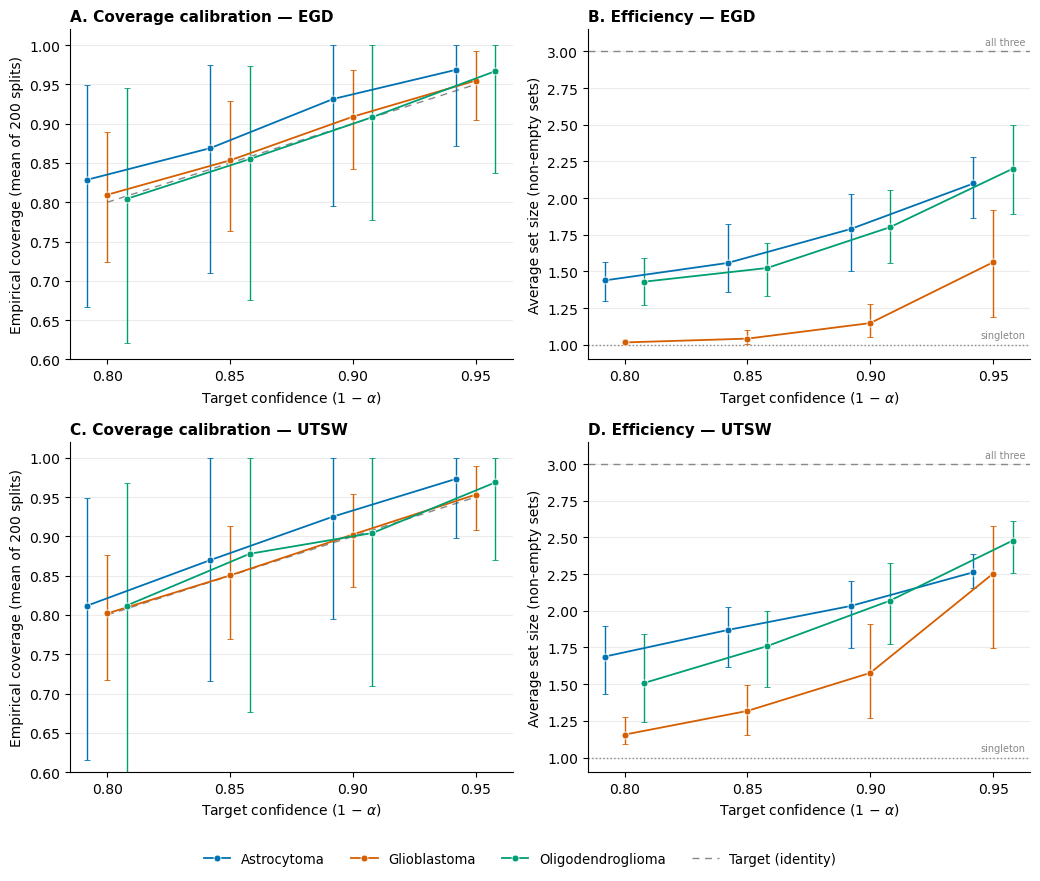

In [28]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

egd = pd.concat([
    pd.read_csv('cp_results_egd_0.8.csv'),
    pd.read_csv('cp_results_egd_0.85.csv'),
    pd.read_csv('cp_results_egd_0.9.csv'),
    pd.read_csv('cp_results_egd_0.95.csv'),
], ignore_index=True)

utsw = pd.concat([
    pd.read_csv('cp_results_utsw_0.8.csv'),
    pd.read_csv('cp_results_utsw_0.85.csv'),
    pd.read_csv('cp_results_utsw_0.9.csv'),
    pd.read_csv('cp_results_utsw_0.95.csv'),
], ignore_index=True)


confs = [0.80, 0.85, 0.90, 0.95]
classes = ['astrocytoma', 'glioblastoma', 'oligodendroglioma']
labels = {'astrocytoma': 'Astrocytoma', 'glioblastoma': 'Glioblastoma', 'oligodendroglioma': 'Oligodendroglioma'}
colors = {'astrocytoma': '#0072B2', 'glioblastoma': '#D55E00', 'oligodendroglioma': '#009E73'}
dodge = {'astrocytoma': -0.008, 'glioblastoma': 0.0, 'oligodendroglioma': 0.008}

summary = {}
for cohort_name, frame in [('EGD', egd), ('UTSW', utsw)]:
    for cls in classes:
        for metric in ['cov', 'size_ge1']:
            means = []
            los = []
            his = []
            for conf in confs:
                values = frame[(frame['target_confidence'] == conf) & (frame['class'] == cls)][metric]
                means.append(values.mean())
                los.append(values.quantile(0.025))
                his.append(values.quantile(0.975))
            summary[(cohort_name, cls, metric)] = (np.array(means), np.array(los), np.array(his))

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'axes.titlesize': 11, 'axes.linewidth': 0.8})
x = np.array(confs)
fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.8))

ax = axes[0, 0]
for cls in classes:
    m, lo, hi = summary[('EGD', cls, 'cov')]
    ax.errorbar(x + dodge[cls], m, yerr=[m - lo, hi - m], marker='o', ms=5, mec='white', mew=0.6,
                lw=1.3, capsize=2.5, elinewidth=1, color=colors[cls])
ax.plot([0.80, 0.95], [0.80, 0.95], ls=(0, (5, 4)), color='#888888', lw=1, zorder=1)
ax.set_title('A. Coverage calibration \u2014 EGD', loc='left', fontweight='bold')
ax.set_xlabel(r'Target confidence (1 $-$ $\alpha$)')
ax.set_ylabel('Empirical coverage (mean of 200 splits)')
ax.set_xticks(confs); ax.set_ylim(0.60, 1.02); ax.set_xlim(0.785, 0.965)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#ececec', lw=0.8); ax.set_axisbelow(True)


ax = axes[0, 1]
for cls in classes:
    m, lo, hi = summary[('EGD', cls, 'size_ge1')]
    ax.errorbar(x + dodge[cls], m, yerr=[m - lo, hi - m], marker='o', ms=5, mec='white', mew=0.6,
                lw=1.3, capsize=2.5, elinewidth=1, color=colors[cls])
ax.axhline(1.0, ls=':', color='#888888', lw=1)
ax.axhline(3.0, ls=(0, (5, 4)), color='#888888', lw=1)
ax.text(0.963, 1.03, 'singleton', fontsize=7, color='#888888', ha='right', va='bottom')
ax.text(0.963, 3.03, 'all three', fontsize=7, color='#888888', ha='right', va='bottom')
ax.set_title('B. Efficiency \u2014 EGD', loc='left', fontweight='bold')
ax.set_xlabel(r'Target confidence (1 $-$ $\alpha$)')
ax.set_ylabel('Average set size (non-empty sets)')
ax.set_xticks(confs); ax.set_ylim(0.9, 3.15); ax.set_xlim(0.785, 0.965)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#ececec', lw=0.8); ax.set_axisbelow(True)

ax = axes[1, 0]
for cls in classes:
    m, lo, hi = summary[('UTSW', cls, 'cov')]
    ax.errorbar(x + dodge[cls], m, yerr=[m - lo, hi - m], marker='o', ms=5, mec='white', mew=0.6,
                lw=1.3, capsize=2.5, elinewidth=1, color=colors[cls])
ax.plot([0.80, 0.95], [0.80, 0.95], ls=(0, (5, 4)), color='#888888', lw=1, zorder=1)
ax.set_title('C. Coverage calibration \u2014 UTSW', loc='left', fontweight='bold')
ax.set_xlabel(r'Target confidence (1 $-$ $\alpha$)')
ax.set_ylabel('Empirical coverage (mean of 200 splits)')
ax.set_xticks(confs); ax.set_ylim(0.60, 1.02); ax.set_xlim(0.785, 0.965)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#ececec', lw=0.8); ax.set_axisbelow(True)


ax = axes[1, 1]
for cls in classes:
    m, lo, hi = summary[('UTSW', cls, 'size_ge1')]
    ax.errorbar(x + dodge[cls], m, yerr=[m - lo, hi - m], marker='o', ms=5, mec='white', mew=0.6,
                lw=1.3, capsize=2.5, elinewidth=1, color=colors[cls])
ax.axhline(1.0, ls=':', color='#888888', lw=1)
ax.axhline(3.0, ls=(0, (5, 4)), color='#888888', lw=1)
ax.text(0.963, 1.03, 'singleton', fontsize=7, color='#888888', ha='right', va='bottom')
ax.text(0.963, 3.03, 'all three', fontsize=7, color='#888888', ha='right', va='bottom')
ax.set_title('D. Efficiency \u2014 UTSW', loc='left', fontweight='bold')
ax.set_xlabel(r'Target confidence (1 $-$ $\alpha$)')
ax.set_ylabel('Average set size (non-empty sets)')
ax.set_xticks(confs); ax.set_ylim(0.9, 3.15); ax.set_xlim(0.785, 0.965)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#ececec', lw=0.8); ax.set_axisbelow(True)


legend_handles = []
legend_labels = []
for cls in classes:
    legend_handles.append(Line2D([0], [0], color=colors[cls], marker='o', ms=5, mec='white', mew=0.6, lw=1.3))
    legend_labels.append(labels[cls])
legend_handles.append(Line2D([0], [0], color='#888888', ls=(0, (5, 4)), lw=1))
legend_labels.append('Target (identity)')
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.004), fontsize=9.5)

plt.tight_layout(rect=[0, 0.045, 1, 1])
plt.savefig(os.path.join(os.getcwd(), 'fig_conformal_coverage_efficiency.png'), dpi=300, bbox_inches='tight')
plt.show()


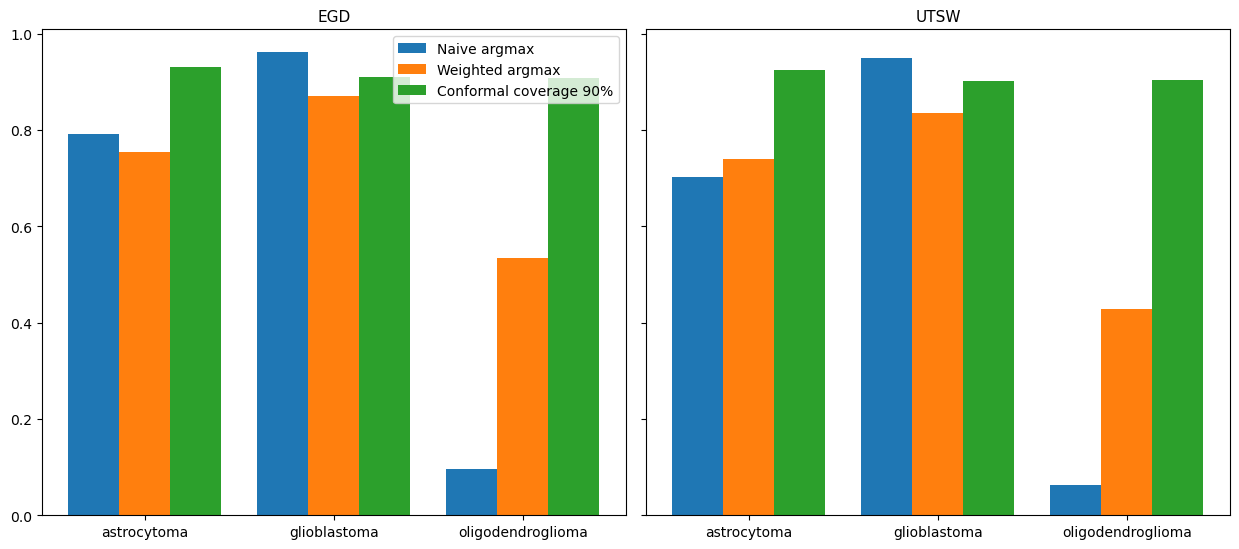

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

classes = np.unique(y_dev_arr)
weights_array = np.array(best_weights_dev, dtype=float)

# EGD recall
egd_argmax_recall = []
egd_weight_recall = []
for cls in classes:
    den = np.sum(y_egd_full == cls)
    egd_argmax_recall.append(np.sum((classes[np.argmax(egd_full_probas, axis=1)] == cls) & (y_egd_full == cls)) / den)
    egd_weight_recall.append(np.sum((classes[np.argmax(egd_full_probas * weights_array, axis=1)] == cls) & (y_egd_full == cls)) / den)

# UTSW recall
utsw_argmax_recall = []
utsw_weight_recall = []
for cls in classes:
    den = np.sum(y_utsw_full == cls)
    utsw_argmax_recall.append(np.sum((classes[np.argmax(utsw_full_probas, axis=1)] == cls) & (y_utsw_full == cls)) / den)
    utsw_weight_recall.append(np.sum((classes[np.argmax(utsw_full_probas * weights_array, axis=1)] == cls) & (y_utsw_full == cls)) / den)

# conformal coverage at 90%
egd90 = pd.read_csv('cp_results_egd_0.9.csv')
utsw90 = pd.read_csv('cp_results_utsw_0.9.csv')
egd_cov = [egd90[egd90['class'] == cls]['cov'].mean() for cls in classes]
utsw_cov = [utsw90[utsw90['class'] == cls]['cov'].mean() for cls in classes]

# plot
w = 0.27
x = np.arange(3)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), sharey=True)

axes[0].bar(x - w, egd_argmax_recall, w, label='Naive argmax')
axes[0].bar(x, egd_weight_recall, w, label='Weighted argmax')
axes[0].bar(x + w, egd_cov, w, label='Conformal coverage 90%')
axes[0].set_title('EGD')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)

axes[1].bar(x - w, utsw_argmax_recall, w, label='Naive argmax')
axes[1].bar(x, utsw_weight_recall, w, label='Weighted argmax')
axes[1].bar(x + w, utsw_cov, w, label='Conformal coverage 90%')
axes[1].set_title('UTSW')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)

axes[0].legend()
plt.tight_layout()
plt.savefig('fig_recall_argmax_weighted_conformal.png', dpi=300)
plt.show()

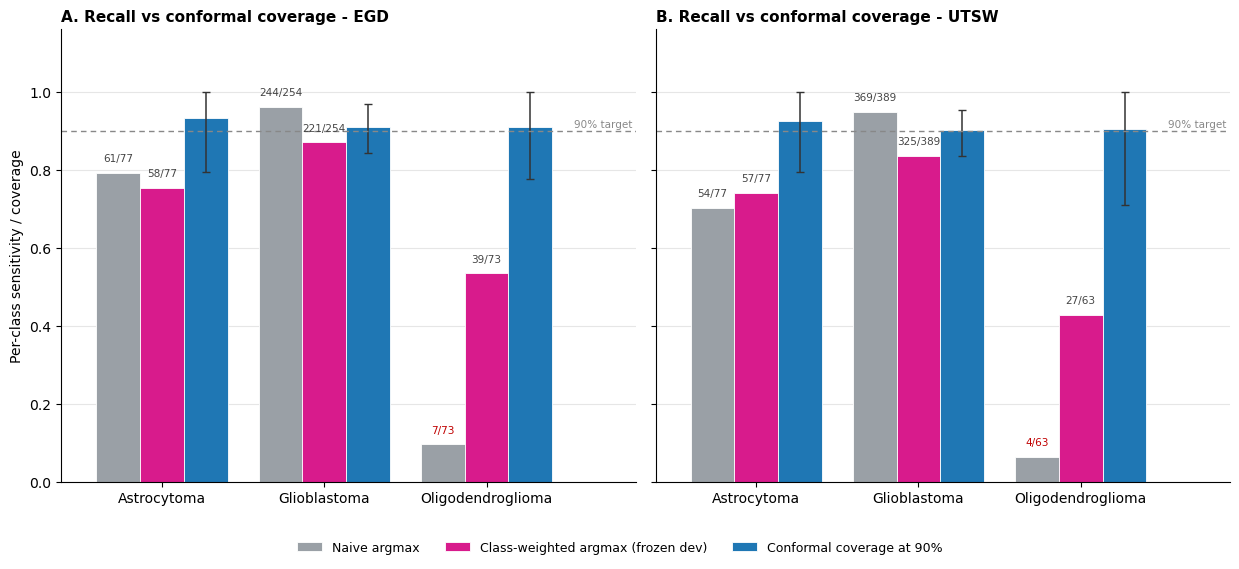

In [40]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

classes = np.unique(y_dev_arr)   # ['astrocytoma','glioblastoma','oligodendroglioma']
short = {'astrocytoma': 'Astrocytoma', 'glioblastoma': 'Glioblastoma', 'oligodendroglioma': 'Oligodendroglioma'}

# EGD: argmax and weighted-argmax recall on the full cohort
egd_pred_argmax = classes[np.argmax(egd_full_probas, axis=1)]
egd_pred_weight = classes[np.argmax(egd_full_probas * np.array(best_weights_dev, dtype=float), axis=1)]

egd_argmax_recall = []
egd_weight_recall = []
egd_argmax_frac = []
egd_weight_frac = []
for cls in classes:
    den = int(np.sum(y_egd_full == cls))
    num_a = int(np.sum((egd_pred_argmax == cls) & (y_egd_full == cls)))
    num_w = int(np.sum((egd_pred_weight == cls) & (y_egd_full == cls)))
    egd_argmax_recall.append(num_a / den)
    egd_weight_recall.append(num_w / den)
    egd_argmax_frac.append(str(num_a) + '/' + str(den))
    egd_weight_frac.append(str(num_w) + '/' + str(den))

# UTSW: same thing
utsw_pred_argmax = classes[np.argmax(utsw_full_probas, axis=1)]
utsw_pred_weight = classes[np.argmax(utsw_full_probas * np.array(best_weights_dev, dtype=float), axis=1)]

utsw_argmax_recall = []
utsw_weight_recall = []
utsw_argmax_frac = []
utsw_weight_frac = []
for cls in classes:
    den = int(np.sum(y_utsw_full == cls))
    num_a = int(np.sum((utsw_pred_argmax == cls) & (y_utsw_full == cls)))
    num_w = int(np.sum((utsw_pred_weight == cls) & (y_utsw_full == cls)))
    utsw_argmax_recall.append(num_a / den)
    utsw_weight_recall.append(num_w / den)
    utsw_argmax_frac.append(str(num_a) + '/' + str(den))
    utsw_weight_frac.append(str(num_w) + '/' + str(den))

# conformal coverage at 90% from the result files (blue bars)
egd90 = pd.read_csv('cp_results_egd_0.9.csv')
utsw90 = pd.read_csv('cp_results_utsw_0.9.csv')

egd_cov_mean, egd_cov_lo, egd_cov_hi = [], [], []
utsw_cov_mean, utsw_cov_lo, utsw_cov_hi = [], [], []
for cls in classes:
    s = egd90[egd90['class'] == cls]['cov']
    egd_cov_mean.append(s.mean()); egd_cov_lo.append(s.quantile(0.025)); egd_cov_hi.append(s.quantile(0.975))
    t = utsw90[utsw90['class'] == cls]['cov']
    utsw_cov_mean.append(t.mean()); utsw_cov_lo.append(t.quantile(0.025)); utsw_cov_hi.append(t.quantile(0.975))

egd_cov_mean = np.array(egd_cov_mean); egd_cov_lo = np.array(egd_cov_lo); egd_cov_hi = np.array(egd_cov_hi)
utsw_cov_mean = np.array(utsw_cov_mean); utsw_cov_lo = np.array(utsw_cov_lo); utsw_cov_hi = np.array(utsw_cov_hi)

# style constants
gray = '#9aa0a6'
pink = '#d81b8c'
blue = '#1f77b4'
w = 0.27
x = np.arange(3)
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 11})

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), sharey=True)


ax = axes[0]
ax.bar(x - w, egd_argmax_recall, w, color=gray, edgecolor='white', linewidth=0.6, label='Naive argmax')
ax.bar(x, egd_weight_recall, w, color=pink, edgecolor='white', linewidth=0.6, label='Class-weighted argmax (frozen dev)')
ax.bar(x + w, egd_cov_mean, w, color=blue, edgecolor='white', linewidth=0.6,
       yerr=[egd_cov_mean - egd_cov_lo, egd_cov_hi - egd_cov_mean], capsize=3,
       error_kw={'ecolor': '#333333', 'elinewidth': 1.1}, label='Conformal coverage at 90%')
for i in range(3):
    color_a = '#c00000' if egd_argmax_recall[i] < 0.10 else '#444444'
    ax.text(x[i] - w, egd_argmax_recall[i] + 0.025, egd_argmax_frac[i], ha='center', va='bottom', fontsize=7.5, color=color_a)
    color_w = '#c00000' if egd_weight_recall[i] < 0.10 else '#444444'
    ax.text(x[i], egd_weight_recall[i] + 0.025, egd_weight_frac[i], ha='center', va='bottom', fontsize=7.5, color=color_w)
ax.axhline(0.90, ls=(0, (4, 3)), color='#888888', linewidth=1)
ax.text(2.9, 0.905, '90% target', ha='right', va='bottom', fontsize=7.5, color='#888888')
ax.set_title('A. Recall vs conformal coverage - EGD', loc='left', fontweight='bold')
ax.set_ylabel('Per-class sensitivity / coverage')
ax.set_xticks(x); ax.set_xticklabels([short[c] for c in classes])
ax.set_ylim(0, 1.16); ax.set_xlim(-0.62, 2.92)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8); ax.set_axisbelow(True)


ax = axes[1]
ax.bar(x - w, utsw_argmax_recall, w, color=gray, edgecolor='white', linewidth=0.6, label='Naive argmax')
ax.bar(x, utsw_weight_recall, w, color=pink, edgecolor='white', linewidth=0.6, label='Class-weighted argmax (frozen dev)')
ax.bar(x + w, utsw_cov_mean, w, color=blue, edgecolor='white', linewidth=0.6,
       yerr=[utsw_cov_mean - utsw_cov_lo, utsw_cov_hi - utsw_cov_mean], capsize=3,
       error_kw={'ecolor': '#333333', 'elinewidth': 1.1}, label='Conformal coverage at 90%')
for i in range(3):
    color_a = '#c00000' if utsw_argmax_recall[i] < 0.10 else '#444444'
    ax.text(x[i] - w, utsw_argmax_recall[i] + 0.025, utsw_argmax_frac[i], ha='center', va='bottom', fontsize=7.5, color=color_a)
    color_w = '#c00000' if utsw_weight_recall[i] < 0.10 else '#444444'
    ax.text(x[i], utsw_weight_recall[i] + 0.025, utsw_weight_frac[i], ha='center', va='bottom', fontsize=7.5, color=color_w)
ax.axhline(0.90, ls=(0, (4, 3)), color='#888888', linewidth=1)
ax.text(2.9, 0.905, '90% target', ha='right', va='bottom', fontsize=7.5, color='#888888')
ax.set_title('B. Recall vs conformal coverage - UTSW', loc='left', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([short[c] for c in classes])
ax.set_ylim(0, 1.16); ax.set_xlim(-0.62, 2.92)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8); ax.set_axisbelow(True)

# shared legend across the top
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=9)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(os.path.join(os.getcwd(), 'fig_recall_argmax_weighted_conformal.png'), dpi=300, bbox_inches='tight')
plt.show()

In [42]:

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight
from crepes import ConformalClassifier
import warnings
warnings.filterwarnings('ignore')


def conformal_point_metrics(y_true, pred_sets, classes):
    y_true_arr = np.array(y_true)
    set_sizes_all = pred_sets.sum(axis=1)
    out = {}
    for i, cls in enumerate(classes):
        cls_mask = (y_true_arr == cls)
        if np.sum(cls_mask) == 0:
            out[cls] = {'cov': np.nan, 'size': np.nan, 'size_ge1': np.nan,
                        'pct_0': np.nan, 'pct_1': np.nan, 'pct_2': np.nan, 'pct_all': np.nan}
            continue
        sizes = set_sizes_all[cls_mask]
        nonempty_sizes = sizes[sizes >= 1]
        if len(nonempty_sizes) > 0:
            size_ge1 = float(np.mean(nonempty_sizes))
        else:
            size_ge1 = np.nan
        out[cls] = {
            'cov': float(np.mean(pred_sets[cls_mask, i])),
            'size': float(np.mean(sizes)),
            'size_ge1': size_ge1,
            'pct_0': float(np.mean(sizes == 0) * 100),
            'pct_1': float(np.mean(sizes == 1) * 100),
            'pct_2': float(np.mean(sizes == 2) * 100),
            'pct_all': float(np.mean(sizes == 3) * 100),
        }
    return out


classes = np.unique(y_dev_arr)
target_confidences = [0.80, 0.85, 0.90, 0.95]
n_seeds = 200

# --- rebuild the preprocessed design matrices with the already-fitted transformers ---
# development cohort (same matrix final_model was trained on)
X_dev_pp = X_dev[feature_cols].replace([np.inf, -np.inf], np.nan)
X_dev_pp = pd.DataFrame(imp.transform(X_dev_pp), columns=X_dev_pp.columns, index=X_dev_pp.index)
X_dev_pp = X_dev_pp[valid_features]
X_dev_pp = pd.DataFrame(dev_scaler.transform(X_dev_pp), columns=X_dev_pp.columns, index=X_dev_pp.index)
X_dev_pp = X_dev_pp.drop(columns=to_drop)
X_dev_pp = X_dev_pp[final_features]

# EGD external cohort
X_egd_pp = df_egd[feature_cols].replace([np.inf, -np.inf], np.nan)
X_egd_pp = pd.DataFrame(imp.transform(X_egd_pp), columns=X_egd_pp.columns, index=X_egd_pp.index)
X_egd_pp = X_egd_pp[valid_features]
X_egd_pp = pd.DataFrame(dev_scaler.transform(X_egd_pp), columns=X_egd_pp.columns, index=X_egd_pp.index)
X_egd_pp = X_egd_pp.drop(columns=to_drop)
X_egd_pp = X_egd_pp[final_features]

# UTSW external cohort
X_utsw_pp = df_utsw[feature_cols].replace([np.inf, -np.inf], np.nan)
X_utsw_pp = pd.DataFrame(imp.transform(X_utsw_pp), columns=X_utsw_pp.columns, index=X_utsw_pp.index)
X_utsw_pp = X_utsw_pp[valid_features]
X_utsw_pp = pd.DataFrame(dev_scaler.transform(X_utsw_pp), columns=X_utsw_pp.columns, index=X_utsw_pp.index)
X_utsw_pp = X_utsw_pp.drop(columns=to_drop)
X_utsw_pp = X_utsw_pp[final_features]

# now gradient boosting derault params
gb_base = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=3, l2_regularization=1.0, random_state=42
)
gb_model = CalibratedClassifierCV(estimator=gb_base, method='sigmoid', cv=5)
sample_w = compute_sample_weight('balanced', y_dev_arr)
gb_model.fit(X_dev_pp[final_features].values, y_dev_arr, sample_weight=sample_w)
print('gradient boosting model trained')


egd_gb_probas = gb_model.predict_proba(X_egd_pp[final_features].values)
utsw_gb_probas = gb_model.predict_proba(X_utsw_pp[final_features].values)

records = []
for cohort_name, full_probas, y_ext in [
        ('EGD', egd_gb_probas, df_egd['2021_glioma_class']),
        ('UTSW-Glioma', utsw_gb_probas, df_utsw['2021_glioma_class'])]:

    full_scores = 1 - full_probas
    y_all = y_ext.values
    row_index = np.arange(len(y_all))

    for seed in range(n_seeds):
        idx_cal, idx_test = train_test_split(row_index, test_size=0.5, random_state=seed, stratify=y_all)
        cal_scores = full_scores[idx_cal]
        te_scores = full_scores[idx_test]
        y_cal = y_all[idx_cal]
        y_test = y_all[idx_test]

        y_cal_idx = np.array([np.where(classes == y)[0][0] for y in y_cal])
        cal_alphas = cal_scores[np.arange(len(y_cal)), y_cal_idx]

        cc = ConformalClassifier()
        cc.fit(cal_alphas, bins=y_cal)

        for conf in target_confidences:
            pred_sets = np.column_stack([
                cc.predict_set(te_scores, bins=np.full(len(y_test), cls), confidence=conf, smoothing=False)[:, c]
                for c, cls in enumerate(classes)
            ])
            point = conformal_point_metrics(y_test, pred_sets, classes)
            for cls in classes:
                m = point[cls]
                records.append({'cohort': cohort_name, 'target_confidence': conf, 'class': cls,
                                'cov': m['cov'], 'size': m['size'], 'size_ge1': m['size_ge1'],
                                'pct_0': m['pct_0'],
                                'pct_1': m['pct_1'], 'pct_2': m['pct_2'], 'pct_all': m['pct_all']})

tidy = pd.DataFrame(records)


n_egd = df_egd['2021_glioma_class'].value_counts().to_dict()
n_utsw = df_utsw['2021_glioma_class'].value_counts().to_dict()
N = {}
N[('EGD', 'astrocytoma')] = int(n_egd['astrocytoma'])
N[('EGD', 'glioblastoma')] = int(n_egd['glioblastoma'])
N[('EGD', 'oligodendroglioma')] = int(n_egd['oligodendroglioma'])
N[('UTSW-Glioma', 'astrocytoma')] = int(n_utsw['astrocytoma'])
N[('UTSW-Glioma', 'glioblastoma')] = int(n_utsw['glioblastoma'])
N[('UTSW-Glioma', 'oligodendroglioma')] = int(n_utsw['oligodendroglioma'])


display_name = {'astrocytoma': 'Astrocytoma', 'glioblastoma': 'Glioblastoma', 'oligodendroglioma': 'Oligodendroglioma'}
subtype_order = ['astrocytoma', 'glioblastoma', 'oligodendroglioma']
conf_order = [0.80, 0.85, 0.90, 0.95]
cohort_order = ['EGD', 'UTSW-Glioma']

table_rows = []
for cohort in cohort_order:
    for conf in conf_order:
        for cls in subtype_order:
            sub = tidy[(tidy['cohort'] == cohort) & (tidy['target_confidence'] == conf) & (tidy['class'] == cls)]
            cov_mean = sub['cov'].mean(); cov_lo = sub['cov'].quantile(0.025); cov_hi = sub['cov'].quantile(0.975)
            size_mean = sub['size'].mean(); size_lo = sub['size'].quantile(0.025); size_hi = sub['size'].quantile(0.975)
            sizege1_mean = sub['size_ge1'].mean(); sizege1_lo = sub['size_ge1'].quantile(0.025); sizege1_hi = sub['size_ge1'].quantile(0.975)
            empty_mean = sub['pct_0'].mean(); empty_lo = sub['pct_0'].quantile(0.025); empty_hi = sub['pct_0'].quantile(0.975)
            single_mean = sub['pct_1'].mean(); single_lo = sub['pct_1'].quantile(0.025); single_hi = sub['pct_1'].quantile(0.975)
            double_mean = sub['pct_2'].mean(); double_lo = sub['pct_2'].quantile(0.025); double_hi = sub['pct_2'].quantile(0.975)
            allthree_mean = sub['pct_all'].mean(); allthree_lo = sub['pct_all'].quantile(0.025); allthree_hi = sub['pct_all'].quantile(0.975)
            row = {}
            row['Cohort'] = cohort
            row['Target confidence'] = str(int(conf * 100)) + '%'
            row['Glioma subtype'] = display_name[cls]
            row['N (cohort)'] = N[(cohort, cls)]
            row['Coverage'] = f"{cov_mean:.2f} [{cov_lo:.2f}-{cov_hi:.2f}]"
            row['Avg. set size'] = f"{size_mean:.2f} [{size_lo:.2f}-{size_hi:.2f}]"
            row['Mean size (>=1)'] = f"{sizege1_mean:.2f} [{sizege1_lo:.2f}-{sizege1_hi:.2f}]"
            row['Abstention'] = f"{empty_mean:.0f} [{empty_lo:.0f}-{empty_hi:.0f}]"
            row['Singleton'] = f"{single_mean:.0f} [{single_lo:.0f}-{single_hi:.0f}]"
            row['Doublet'] = f"{double_mean:.0f} [{double_lo:.0f}-{double_hi:.0f}]"
            row['All-three'] = f"{allthree_mean:.0f} [{allthree_lo:.0f}-{allthree_hi:.0f}]"
            table_rows.append(row)

tableS1 = pd.DataFrame(table_rows)
tableS1.to_csv(os.path.join(os.getcwd(), 'tableS1_conformal_gb.csv'), index=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print(tableS1.to_string(index=False))

gradient boosting model trained
     Cohort Target confidence    Glioma subtype  N (cohort)         Coverage    Avg. set size  Mean size (>=1) Abstention  Singleton    Doublet  All-three
        EGD               80%       Astrocytoma          77 0.84 [0.66-0.97] 1.42 [1.18-1.61] 1.43 [1.22-1.61]    0 [0-3] 57 [39-77] 42 [21-61]    0 [0-0]
        EGD               80%      Glioblastoma         254 0.81 [0.72-0.89] 0.98 [0.89-1.06] 1.04 [1.00-1.09]   6 [2-12] 90 [85-94]    4 [0-9]    0 [0-0]
        EGD               80% Oligodendroglioma          73 0.80 [0.59-0.94] 1.33 [1.08-1.51] 1.39 [1.17-1.54]   4 [0-11] 59 [44-78] 37 [16-54]    0 [0-0]
        EGD               85%       Astrocytoma          77 0.88 [0.67-0.97] 1.54 [1.34-1.71] 1.54 [1.35-1.71]    0 [0-3] 46 [29-63] 54 [34-71]    0 [0-0]
        EGD               85%      Glioblastoma         254 0.85 [0.77-0.93] 1.08 [1.00-1.17] 1.09 [1.04-1.17]    2 [0-6] 89 [83-94]   9 [4-17]    0 [0-0]
        EGD               85% Oligoden

In [41]:
import os
import numpy as np
import pandas as pd
from crepes import ConformalClassifier
import warnings
warnings.filterwarnings('ignore')


def conformal_point_metrics(y_true, pred_sets, classes):
    y_true_arr = np.array(y_true)
    set_sizes_all = pred_sets.sum(axis=1)
    out = {}
    for i, cls in enumerate(classes):
        cls_mask = (y_true_arr == cls)
        if np.sum(cls_mask) == 0:
            out[cls] = {'cov': np.nan, 'size': np.nan, 'size_ge1': np.nan,
                        'pct_0': np.nan, 'pct_1': np.nan, 'pct_2': np.nan, 'pct_all': np.nan}
            continue
        sizes = set_sizes_all[cls_mask]
        nonempty_sizes = sizes[sizes >= 1]
        if len(nonempty_sizes) > 0:
            size_ge1 = float(np.mean(nonempty_sizes))
        else:
            size_ge1 = np.nan
        out[cls] = {
            'cov': float(np.mean(pred_sets[cls_mask, i])),
            'size': float(np.mean(sizes)),
            'size_ge1': size_ge1,
            'pct_0': float(np.mean(sizes == 0) * 100),
            'pct_1': float(np.mean(sizes == 1) * 100),
            'pct_2': float(np.mean(sizes == 2) * 100),
            'pct_all': float(np.mean(sizes == 3) * 100),
        }
    return out


classes = np.unique(y_dev_arr)
target_confidences = [0.80, 0.85, 0.90, 0.95]
n_reps = 200
rng = np.random.default_rng(42)

# fit the conformal predictor ONCE on the development OOF scores
dev_scores = 1 - oof_probas
y_dev_idx = np.array([np.where(classes == y)[0][0] for y in y_dev_arr])
dev_alphas = dev_scores[np.arange(len(y_dev_arr)), y_dev_idx]

cc = ConformalClassifier()
cc.fit(dev_alphas, bins=y_dev_arr)
print('conformal predictor calibrated on development OOF scores')

# apply directly to each full external cohort.. bootstrap for the band
records = []
for cohort_name, full_probas, y_ext in [
        ('EGD', egd_full_probas, y_egd_full),
        ('UTSW-Glioma', utsw_full_probas, y_utsw_full)]:

    te_scores = 1 - full_probas
    y_test = np.array(y_ext)

    for conf in target_confidences:
        # prediction sets are fixed once calibration and probabilities are fixed
        pred_sets = np.column_stack([
            cc.predict_set(te_scores, bins=np.full(len(y_test), cls), confidence=conf, smoothing=False)[:, c]
            for c, cls in enumerate(classes)
        ])

        # stratified bootstrap of the external cohort (preserves per-class N)
        class_indices = {}
        for cls in classes:
            class_indices[cls] = np.where(y_test == cls)[0]

        for rep in range(n_reps):
            boot_parts = []
            for cls in classes:
                ci = class_indices[cls]
                boot_parts.append(rng.choice(ci, size=len(ci), replace=True))
            boot = np.concatenate(boot_parts)

            point = conformal_point_metrics(y_test[boot], pred_sets[boot], classes)
            for cls in classes:
                m = point[cls]
                records.append({'cohort': cohort_name, 'target_confidence': conf, 'class': cls,
                                'cov': m['cov'], 'size': m['size'], 'size_ge1': m['size_ge1'],
                                'pct_0': m['pct_0'],
                                'pct_1': m['pct_1'], 'pct_2': m['pct_2'], 'pct_all': m['pct_all']})

tidy = pd.DataFrame(records)


n_egd = df_egd['2021_glioma_class'].value_counts().to_dict()
n_utsw = df_utsw['2021_glioma_class'].value_counts().to_dict()
N = {}
N[('EGD', 'astrocytoma')] = int(n_egd['astrocytoma'])
N[('EGD', 'glioblastoma')] = int(n_egd['glioblastoma'])
N[('EGD', 'oligodendroglioma')] = int(n_egd['oligodendroglioma'])
N[('UTSW-Glioma', 'astrocytoma')] = int(n_utsw['astrocytoma'])
N[('UTSW-Glioma', 'glioblastoma')] = int(n_utsw['glioblastoma'])
N[('UTSW-Glioma', 'oligodendroglioma')] = int(n_utsw['oligodendroglioma'])


display_name = {'astrocytoma': 'Astrocytoma', 'glioblastoma': 'Glioblastoma', 'oligodendroglioma': 'Oligodendroglioma'}
subtype_order = ['astrocytoma', 'glioblastoma', 'oligodendroglioma']
conf_order = [0.80, 0.85, 0.90, 0.95]
cohort_order = ['EGD', 'UTSW-Glioma']

table_rows = []
for cohort in cohort_order:
    for conf in conf_order:
        for cls in subtype_order:
            sub = tidy[(tidy['cohort'] == cohort) & (tidy['target_confidence'] == conf) & (tidy['class'] == cls)]
            cov_mean = sub['cov'].mean(); cov_lo = sub['cov'].quantile(0.025); cov_hi = sub['cov'].quantile(0.975)
            size_mean = sub['size'].mean(); size_lo = sub['size'].quantile(0.025); size_hi = sub['size'].quantile(0.975)
            sizege1_mean = sub['size_ge1'].mean(); sizege1_lo = sub['size_ge1'].quantile(0.025); sizege1_hi = sub['size_ge1'].quantile(0.975)
            empty_mean = sub['pct_0'].mean(); empty_lo = sub['pct_0'].quantile(0.025); empty_hi = sub['pct_0'].quantile(0.975)
            single_mean = sub['pct_1'].mean(); single_lo = sub['pct_1'].quantile(0.025); single_hi = sub['pct_1'].quantile(0.975)
            double_mean = sub['pct_2'].mean(); double_lo = sub['pct_2'].quantile(0.025); double_hi = sub['pct_2'].quantile(0.975)
            allthree_mean = sub['pct_all'].mean(); allthree_lo = sub['pct_all'].quantile(0.025); allthree_hi = sub['pct_all'].quantile(0.975)
            row = {}
            row['Cohort'] = cohort
            row['Target confidence'] = str(int(conf * 100)) + '%'
            row['Glioma subtype'] = display_name[cls]
            row['N (cohort)'] = N[(cohort, cls)]
            row['Coverage'] = f"{cov_mean:.2f} [{cov_lo:.2f}-{cov_hi:.2f}]"
            row['Avg. set size'] = f"{size_mean:.2f} [{size_lo:.2f}-{size_hi:.2f}]"
            row['Mean size (>=1)'] = f"{sizege1_mean:.2f} [{sizege1_lo:.2f}-{sizege1_hi:.2f}]"
            row['Abstention'] = f"{empty_mean:.0f} [{empty_lo:.0f}-{empty_hi:.0f}]"
            row['Singleton'] = f"{single_mean:.0f} [{single_lo:.0f}-{single_hi:.0f}]"
            row['Doublet'] = f"{double_mean:.0f} [{double_lo:.0f}-{double_hi:.0f}]"
            row['All-three'] = f"{allthree_mean:.0f} [{allthree_lo:.0f}-{allthree_hi:.0f}]"
            table_rows.append(row)

tableS2 = pd.DataFrame(table_rows)
tableS2.to_csv(os.path.join(os.getcwd(), 'tableS2_conformal_devcal.csv'), index=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print(tableS2.to_string(index=False))

conformal predictor calibrated on development OOF scores
     Cohort Target confidence    Glioma subtype  N (cohort)         Coverage    Avg. set size  Mean size (>=1) Abstention  Singleton       Doublet  All-three
        EGD               80%       Astrocytoma          77 0.83 [0.74-0.91] 1.74 [1.65-1.83] 1.76 [1.68-1.85]    1 [0-4] 23 [14-32]    75 [66-84]    0 [0-0]
        EGD               80%      Glioblastoma         254 0.68 [0.63-0.73] 0.94 [0.89-0.98] 1.06 [1.03-1.10]  12 [8-16] 83 [78-87]       5 [3-9]    0 [0-0]
        EGD               80% Oligodendroglioma          73 0.95 [0.89-0.99] 1.49 [1.37-1.60] 1.51 [1.39-1.60]    1 [0-4] 49 [40-60]    50 [38-60]    0 [0-0]
        EGD               85%       Astrocytoma          77 0.96 [0.92-1.00] 1.93 [1.86-1.97] 1.95 [1.89-2.00]    1 [0-4]   5 [0-10]    94 [88-97]    0 [0-0]
        EGD               85%      Glioblastoma         254 0.78 [0.72-0.83] 1.09 [1.05-1.13] 1.13 [1.09-1.18]    3 [2-6] 84 [79-88]     13 [9-17]    0 [

In [43]:

import os
import numpy as np
import pandas as pd

n_bins = 15
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
classes = np.unique(y_dev_arr)   # ['astrocytoma','glioblastoma','oligodendroglioma']

def compute_ece(confidence, outcome, edges):
    confidence = np.asarray(confidence, dtype=float)
    outcome = np.asarray(outcome, dtype=float)
    n_total = len(confidence)
    ece = 0.0
    for b in range(len(edges) - 1):
        low = edges[b]
        high = edges[b + 1]
        if b == 0:
            in_bin = (confidence >= low) & (confidence <= high)
        else:
            in_bin = (confidence > low) & (confidence <= high)
        n_in = np.sum(in_bin)
        if n_in == 0:
            continue
        mean_conf = np.mean(confidence[in_bin])
        mean_out = np.mean(outcome[in_bin])
        ece = ece + (n_in / n_total) * abs(mean_out - mean_conf)
    return ece


eval_sets = [
    ('Development (OOF)', oof_probas, y_dev_arr),
    ('EGD (full)', egd_full_probas, y_egd_full),
    ('UTSW (full)', utsw_full_probas, y_utsw_full),
]

rows = []
for set_name, probas, y_true in eval_sets:
    probas = np.asarray(probas, dtype=float)
    y_true = np.asarray(y_true)

    top_conf = np.max(probas, axis=1)
    pred_idx = np.argmax(probas, axis=1)
    pred_label = classes[pred_idx]
    top_hit = (pred_label == y_true).astype(float)
    top_ece = compute_ece(top_conf, top_hit, bin_edges)

    per_class_ece = []
    for c, cls in enumerate(classes):
        class_conf = probas[:, c]
        class_outcome = (y_true == cls).astype(float)
        per_class_ece.append(compute_ece(class_conf, class_outcome, bin_edges))

    classwise_mean = float(np.mean(per_class_ece))

    row = {}
    row['Evaluation set'] = set_name
    row['Top-label ECE'] = round(top_ece, 3)
    row['Class-wise ECE (mean)'] = round(classwise_mean, 3)
    row['ECE Astro'] = round(per_class_ece[0], 3)
    row['ECE GBM'] = round(per_class_ece[1], 3)
    row['ECE Oligo'] = round(per_class_ece[2], 3)
    rows.append(row)

tableS4 = pd.DataFrame(rows)
tableS4.to_csv(os.path.join(os.getcwd(), 'tableS4_calibration_ece.csv'), index=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print(tableS4.to_string(index=False))

   Evaluation set  Top-label ECE  Class-wise ECE (mean)  ECE Astro  ECE GBM  ECE Oligo
Development (OOF)          0.050                  0.033      0.039    0.041      0.020
       EGD (full)          0.074                  0.092      0.082    0.087      0.107
      UTSW (full)          0.050                  0.068      0.076    0.057      0.070


In [47]:

import numpy as np
import pandas as pd

importances_per_fold = []
for cal in final_model.calibrated_classifiers_:
    fitted_rf = getattr(cal, 'estimator', None)
    if fitted_rf is None:
        fitted_rf = getattr(cal, 'base_estimator', None)   # older sklearn attribute name
    importances_per_fold.append(fitted_rf.feature_importances_)

importances_array = np.array(importances_per_fold)   # shape (5, n_features)
importance_mean = importances_array.mean(axis=0)
importance_std = importances_array.std(axis=0)


fi = pd.DataFrame({
    'feature': final_features,
    'importance_mean': importance_mean,
    'importance_std': importance_std,
})
fi = fi.sort_values('importance_mean', ascending=False).reset_index(drop=True)
fi['rank'] = np.arange(1, len(fi) + 1)
fi = fi[['rank', 'feature', 'importance_mean', 'importance_std']]

fi_display = fi.copy()
fi_display['importance_mean'] = fi_display['importance_mean'].round(4)
fi_display['importance_std'] = fi_display['importance_std'].round(4)

fi.to_csv(os.path.join(os.getcwd(), 'feature_importances_final.csv'), index=False)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 160)
print('Feature importances (mean over the 5 calibration-fold forests, impurity-based):')
print(fi_display.to_string(index=False))
print()
print('Sum of mean importances:', round(importance_mean.sum(), 4))

Feature importances (mean over the 5 calibration-fold forests, impurity-based):
 rank                                                         feature  importance_mean  importance_std
    1                           T1CE_original_firstorder_90Percentile           0.0961          0.0114
    2                              T1CE_log-sigma-1-0-mm-3D_glcm_Imc2           0.0822          0.0088
    3                           T1CE_original_firstorder_10Percentile           0.0730          0.0056
    4                              T1CE_wavelet-LHL_glszm_ZoneEntropy           0.0597          0.0116
    5                              T1CE_wavelet-LLH_glszm_ZoneEntropy           0.0593          0.0101
    6 T1CE_log-sigma-1-0-mm-3D_glszm_GrayLevelNonUniformityNormalized           0.0586          0.0090
    7                              T1CE_wavelet-LHH_glszm_ZoneEntropy           0.0547          0.0121
    8         T1CE_wavelet-LHL_glszm_GrayLevelNonUniformityNormalized           0.0510          

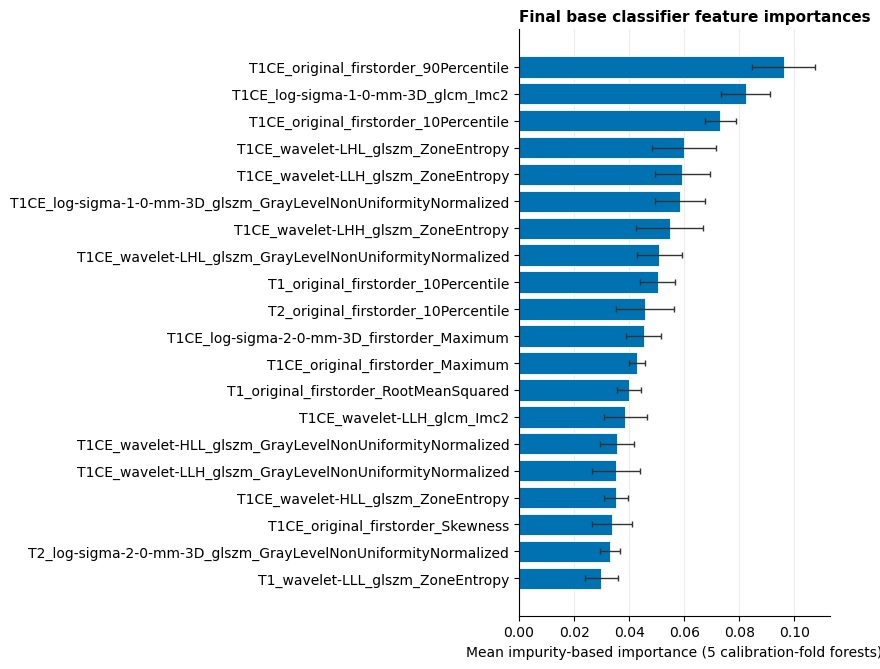

In [48]:

import os
import numpy as np
import matplotlib.pyplot as plt

feat = list(fi['feature'])
mean = fi['importance_mean'].values
std = fi['importance_std'].values
y = np.arange(len(feat))

fig, ax = plt.subplots(figsize=(8.5, max(4.0, 0.34 * len(feat))))
ax.barh(y, mean, xerr=std, color='#0072B2', edgecolor='white', linewidth=0.6,
        error_kw={'ecolor': '#333333', 'elinewidth': 1.0, 'capsize': 2.5})
ax.set_yticks(y)
ax.set_yticklabels(feat)
ax.invert_yaxis()   # rank 1 ends up at the top
ax.set_xlabel('Mean impurity-based importance (5 calibration-fold forests)')
ax.set_title('Final base classifier feature importances', loc='left', fontweight='bold')
ax.set_xlim(left=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, color='#ececec', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), 'fig_feature_importances_final.png'), dpi=300, bbox_inches='tight')
plt.show()

In [65]:
import os
import numpy as np
import pandas as pd
from crepes import ConformalClassifier
import warnings
warnings.filterwarnings('ignore')



def conformal_point_metrics(y_true, pred_sets, classes):
    y_true_arr = np.array(y_true)
    set_sizes_all = pred_sets.sum(axis=1)
    out = {}
    for i, cls in enumerate(classes):
        cls_mask = (y_true_arr == cls)
        if np.sum(cls_mask) == 0:
            out[cls] = {'cov': np.nan, 'size': np.nan, 'size_ge1': np.nan,
                        'pct_0': np.nan, 'pct_1': np.nan, 'pct_2': np.nan, 'pct_all': np.nan}
            continue
        sizes = set_sizes_all[cls_mask]
        nonempty_sizes = sizes[sizes >= 1]
        if len(nonempty_sizes) > 0:
            size_ge1 = float(np.mean(nonempty_sizes))
        else:
            size_ge1 = np.nan
        out[cls] = {
            'cov': float(np.mean(pred_sets[cls_mask, i])),
            'size': float(np.mean(sizes)),
            'size_ge1': size_ge1,
            'pct_0': float(np.mean(sizes == 0) * 100),
            'pct_1': float(np.mean(sizes == 1) * 100),
            'pct_2': float(np.mean(sizes == 2) * 100),
            'pct_all': float(np.mean(sizes == 3) * 100),
        }
    return out


classes = np.unique(y_dev_arr)
target_confidences = [0.80, 0.85, 0.90, 0.95]

# development out-of-fold nonconformity scores (1 - calibrated prob), computed once
full_scores = 1 - oof_probas
y_all = np.array(y_dev_arr)
n_dev_cases = len(y_all)

# fold_assignments was filled in the 5-fold training step
fold_ids = np.unique(fold_assignments)

# one fixed (n_dev_cases x 3) prediction-set matrix per confidence level
pred_sets_by_conf = {}
for conf in target_confidences:
    pred_sets_by_conf[conf] = np.zeros((n_dev_cases, len(classes)), dtype=int)

for k in fold_ids:

    cal_mask = (fold_assignments != k)
    test_mask = (fold_assignments == k)

    cal_scores = full_scores[cal_mask]
    y_cal = y_all[cal_mask]
    te_scores = full_scores[test_mask]
    test_positions = np.where(test_mask)[0]

    # nonconformity score of the true class for each calibration case
    y_cal_idx = np.array([np.where(classes == y)[0][0] for y in y_cal])
    cal_alphas = cal_scores[np.arange(len(y_cal)), y_cal_idx]

    # class-conditional (Mondrian) calibration on the other four folds
    cc_dev = ConformalClassifier()
    cc_dev.fit(cal_alphas, bins=y_cal)

    for conf in target_confidences:

        col0 = cc_dev.predict_set(te_scores, bins=np.full(len(te_scores), classes[0]), confidence=conf, smoothing=False)[:, 0]
        col1 = cc_dev.predict_set(te_scores, bins=np.full(len(te_scores), classes[1]), confidence=conf, smoothing=False)[:, 1]
        col2 = cc_dev.predict_set(te_scores, bins=np.full(len(te_scores), classes[2]), confidence=conf, smoothing=False)[:, 2]
        fold_sets = np.column_stack([col0, col1, col2])

        
        pred_sets_by_conf[conf][test_positions, :] = fold_sets

print('leave-one-fold-out cross-conformal prediction sets built for', len(fold_ids), 'folds')


# point estimate: per-class coverage and set-size composition on the full pooled cohort
point_by_conf = {}
for conf in target_confidences:
    point_by_conf[conf] = conformal_point_metrics(y_all, pred_sets_by_conf[conf], classes)


# uncertainty band
n_boot = 1000
rng = np.random.default_rng(42)

class_positions = {}
for cls in classes:
    class_positions[cls] = np.where(y_all == cls)[0]

boot_by_conf = {}
for conf in target_confidences:
    boot_by_conf[conf] = {cls: {'cov': [], 'size_ge1': [], 'pct_1': [], 'pct_2': [], 'pct_all': []} for cls in classes}

for b in range(n_boot):

    boot_parts = []
    for cls in classes:
        positions = class_positions[cls]
        boot_parts.append(rng.choice(positions, size=len(positions), replace=True))
    boot_idx = np.concatenate(boot_parts)

    y_boot = y_all[boot_idx]
    for conf in target_confidences:
        sets_boot = pred_sets_by_conf[conf][boot_idx, :]
        point_boot = conformal_point_metrics(y_boot, sets_boot, classes)
        for cls in classes:
            boot_by_conf[conf][cls]['cov'].append(point_boot[cls]['cov'])
            boot_by_conf[conf][cls]['size_ge1'].append(point_boot[cls]['size_ge1'])
            boot_by_conf[conf][cls]['pct_1'].append(point_boot[cls]['pct_1'])
            boot_by_conf[conf][cls]['pct_2'].append(point_boot[cls]['pct_2'])
            boot_by_conf[conf][cls]['pct_all'].append(point_boot[cls]['pct_all'])


# assemble the table: deterministic point estimate with bootstrap 2.5-97.5 percentile band
n_dev = pd.Series(y_dev_arr).value_counts().to_dict()
N = {}
N['astrocytoma'] = int(n_dev['astrocytoma'])
N['glioblastoma'] = int(n_dev['glioblastoma'])
N['oligodendroglioma'] = int(n_dev['oligodendroglioma'])

display_name = {'astrocytoma': 'Astrocytoma', 'glioblastoma': 'Glioblastoma', 'oligodendroglioma': 'Oligodendroglioma'}
subtype_order = ['astrocytoma', 'glioblastoma', 'oligodendroglioma']
conf_order = [0.80, 0.85, 0.90, 0.95]

table_rows = []
for conf in conf_order:
    for cls in subtype_order:

        cov_point = point_by_conf[conf][cls]['cov']
        cov_lo = float(np.nanpercentile(boot_by_conf[conf][cls]['cov'], 2.5))
        cov_hi = float(np.nanpercentile(boot_by_conf[conf][cls]['cov'], 97.5))

        size_point = point_by_conf[conf][cls]['size_ge1']
        size_lo = float(np.nanpercentile(boot_by_conf[conf][cls]['size_ge1'], 2.5))
        size_hi = float(np.nanpercentile(boot_by_conf[conf][cls]['size_ge1'], 97.5))

        single_point = point_by_conf[conf][cls]['pct_1']
        single_lo = float(np.nanpercentile(boot_by_conf[conf][cls]['pct_1'], 2.5))
        single_hi = float(np.nanpercentile(boot_by_conf[conf][cls]['pct_1'], 97.5))

        double_point = point_by_conf[conf][cls]['pct_2']
        double_lo = float(np.nanpercentile(boot_by_conf[conf][cls]['pct_2'], 2.5))
        double_hi = float(np.nanpercentile(boot_by_conf[conf][cls]['pct_2'], 97.5))

        allthree_point = point_by_conf[conf][cls]['pct_all']
        allthree_lo = float(np.nanpercentile(boot_by_conf[conf][cls]['pct_all'], 2.5))
        allthree_hi = float(np.nanpercentile(boot_by_conf[conf][cls]['pct_all'], 97.5))

        row = {}
        row['Cohort'] = 'Development (internal)'
        row['Target confidence'] = str(int(conf * 100)) + '%'
        row['Glioma subtype'] = display_name[cls]
        row['N (cohort)'] = N[cls]
        row['Coverage'] = f"{cov_point:.2f} [{cov_lo:.2f}-{cov_hi:.2f}]"
        row['Mean size (>=1)'] = f"{size_point:.2f} [{size_lo:.2f}-{size_hi:.2f}]"
        row['Singleton'] = f"{single_point:.0f} [{single_lo:.0f}-{single_hi:.0f}]"
        row['Doublet'] = f"{double_point:.0f} [{double_lo:.0f}-{double_hi:.0f}]"
        row['All-three'] = f"{allthree_point:.0f} [{allthree_lo:.0f}-{allthree_hi:.0f}]"
        table_rows.append(row)

table3_dev = pd.DataFrame(table_rows)
table3_dev.to_csv(os.path.join(os.getcwd(), 'table3_dev_reference.csv'), index=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print(table3_dev.to_string(index=False))

leave-one-fold-out cross-conformal prediction sets built for 5 folds
                Cohort Target confidence    Glioma subtype  N (cohort)         Coverage  Mean size (>=1)  Singleton    Doublet  All-three
Development (internal)               80%       Astrocytoma         133 0.81 [0.74-0.87] 1.61 [1.53-1.69] 37 [29-45] 58 [50-65]    0 [0-0]
Development (internal)               80%      Glioblastoma         452 0.80 [0.76-0.83] 1.03 [1.02-1.05] 90 [87-92]    3 [2-5]    0 [0-0]
Development (internal)               80% Oligodendroglioma          26 0.81 [0.65-0.96] 1.52 [1.32-1.71] 46 [27-65] 50 [31-69]    0 [0-0]
Development (internal)               85%       Astrocytoma         133 0.83 [0.77-0.89] 1.78 [1.71-1.85] 22 [15-29] 76 [69-83]    0 [0-0]
Development (internal)               85%      Glioblastoma         452 0.85 [0.82-0.88] 1.14 [1.11-1.17] 84 [81-87] 14 [11-17]    0 [0-0]
Development (internal)               85% Oligodendroglioma          26 0.88 [0.77-1.00] 1.64 [1.45-1.81

In [64]:
import os
import pandas as pd

scope_all = selection
scope_egd = selection[selection['cohort'] == 'EGD']
scope_utsw = selection[selection['cohort'] == 'UTSW']

scopes = [('All external', scope_all), ('EGD', scope_egd), ('UTSW', scope_utsw)]

rows = []
for scope_name, d in scopes:

    n = len(d)

    # --- 90% target ---
    n_single_90 = int((d['set90_size'] == 1).sum())
    n_single_correct_90 = int(((d['set90_size'] == 1) & (d['covers90'] == True)).sum())
    n_defer_90 = int((d['set90_size'] >= 2).sum())
    n_abstain_90 = int((d['set90_size'] == 0).sum())

    yield_90 = n_single_90 / n * 100
    defer_90 = n_defer_90 / n * 100
    abstain_90 = n_abstain_90 / n * 100
    if n_single_90 > 0:
        sel_acc_90 = n_single_correct_90 / n_single_90 * 100
    else:
        sel_acc_90 = float('nan')

    row_90 = {}
    row_90['Cohort'] = scope_name
    row_90['Target'] = '90%'
    row_90['N'] = n
    row_90['Single-label yield (%)'] = round(yield_90, 1)
    row_90['Selective accuracy (%)'] = round(sel_acc_90, 1)
    row_90['Defer to molecular (%)'] = round(defer_90, 1)
    row_90['Abstain (%)'] = round(abstain_90, 1)
    rows.append(row_90)

    # --- 95% target ---
    n_single_95 = int((d['set95_size'] == 1).sum())
    n_single_correct_95 = int(((d['set95_size'] == 1) & (d['covers95'] == True)).sum())
    n_defer_95 = int((d['set95_size'] >= 2).sum())
    n_abstain_95 = int((d['set95_size'] == 0).sum())

    yield_95 = n_single_95 / n * 100
    defer_95 = n_defer_95 / n * 100
    abstain_95 = n_abstain_95 / n * 100
    if n_single_95 > 0:
        sel_acc_95 = n_single_correct_95 / n_single_95 * 100
    else:
        sel_acc_95 = float('nan')

    row_95 = {}
    row_95['Cohort'] = scope_name
    row_95['Target'] = '95%'
    row_95['N'] = n
    row_95['Single-label yield (%)'] = round(yield_95, 1)
    row_95['Selective accuracy (%)'] = round(sel_acc_95, 1)
    row_95['Defer to molecular (%)'] = round(defer_95, 1)
    row_95['Abstain (%)'] = round(abstain_95, 1)
    rows.append(row_95)

triage = pd.DataFrame(rows)
triage.to_csv(os.path.join(os.getcwd(), 'triage_operating_point.csv'), index=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(triage.to_string(index=False))

      Cohort Target   N  Single-label yield (%)  Selective accuracy (%)  Defer to molecular (%)  Abstain (%)
All external    90% 467                    53.1                    93.5                    46.7          0.2
All external    95% 467                    22.3                    99.0                    77.7          0.0
         EGD    90% 202                    64.4                    90.8                    35.1          0.5
         EGD    95% 202                    20.8                   100.0                    79.2          0.0
        UTSW    90% 265                    44.5                    96.6                    55.5          0.0
        UTSW    95% 265                    23.4                    98.4                    76.6          0.0
